# **Нелинейные модели против южной погоды**

---

**Описание исследования**

Необходимо построить модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов по погодным и календарным условиям. Задача регрессии - предсказать числовое значение целевой переменной по набору факторов, чтобы улучшить точность прогнозов и стабилизировать логистику (избежать дефицита и простоев велосипедов).​

---

**Цель исследования**

Разработать и обучить модель машинного обучения для прогнозирования почасового спроса на велопрокат.

- Целевая переменная: Rented Bike Count (регрессия).
- Базовое решение: оценить предоставленный заказчиком pipeline с линейной регрессией (pickle) на train и test по метрикам RMSE, R^2, MAE.
- Основные модели для улучшения: kNN-регрессия и дерево решений + подбор гиперпараметров через Optuna (подход define-by-run).​
- Основная метрика для оптимизации: RMSE (минимизация); для корректной работы со scoring в cross_val_score использовать neg_root_mean_squared_error 

---

**Задачи исследования**

- Подготовка среды и загрузка данных.
- Запуск baseline-пайплайна с линейной регрессией (pickle) и оценка RMSE/R^2/MAE на train и test.
- EDA и подготовка данных (типы, пропуски, распределение Rented Bike Count, гипотезы о нелинейностях).
- Обучение и подбор гиперпараметров kNN и дерева решений с Optuna.
- Сравнение лучших моделей, выбор победителя и единственная финальная проверка на test.
- Интерпретация (важность признаков) и выводы/рекомендации для BikeSouth.

---

Файлы: ds_s14_train_data.csv (обучение/валидация) и ds_s14_test_data.csv (финальная оценка).

Признаки: 
- погодные (Temperature, Humidity, Windspeed, Visibility, Dew Point Temperature, Solar Radiation, Rainfall, Snowfall)

- сезон/календарь (Seasons, Holiday, Functioning Day)

- временные периоды (Time_Period*, где Daytime - базовый период)

Целевая переменная: Rented Bike Count.

---

## Подготовка среды и библиотек

#### 1.1 Подготовка библиотек


In [143]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU numpy scipy scikit-learn==1.6.1 pandas matplotlib seaborn phik joblib category_encoders optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [144]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold, RFE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

from IPython.display import display

pd.set_option('display.max_columns', None)

In [145]:
print(sklearn.__version__) 

1.6.1


In [146]:
RANDOM_STATE=42

---

In [147]:
def get_df(path):
    return pd.read_csv(path, sep=',', decimal='.')

base_path = '/datasets/'
train_pth1 = Path(f'.{base_path}ds_s14_train_data.csv')
train_pth2 = Path(f'{base_path}ds_s14_train_data.csv')

test_pth1 = Path(f'.{base_path}ds_s14_test_data.csv')
test_pth2 = Path(f'{base_path}ds_s14_test_data.csv')

baseline_pth1 = Path('./models/baseline_linear_regression_pipeline.pkl')
baseline_pth2 = Path(f'{base_path}baseline_linear_regression_pipeline.pkl')

if train_pth1.exists() and test_pth1.exists() and baseline_pth1.exists():
    train = get_df(train_pth1)
    test = get_df(test_pth1)
    baseline = joblib.load(baseline_pth1)
elif train_pth2.exists() and test_pth2.exists() and baseline_pth2.exists():
    train = get_df(train_pth2)
    test = get_df(test_pth2)
    baseline = joblib.load(baseline_pth2)
else:
    raise "Путь до датасета неверный"

In [148]:
print('train')
display(train.head())
train.info()
print()
print('test')
display(test.head())
test.info()

train


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

---

### Разделение данных

In [149]:
X = train.drop(columns=['Rented Bike Count'])
y = train['Rented Bike Count']

In [150]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    test_size=.2,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train_val.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (5606, 15)
Размер тестовой выборки: (1402, 15)
Среднее значенее целевой переменной в train: 705.099
Среднее значенее целевой переменной в test: 707.633


---

### Анализ Baseline модели

In [151]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [152]:
def compute_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

wape_scorer = make_scorer(compute_wape, greater_is_better=False)

In [153]:
def show_metrics(name, pipeline):
    scoring = {
        "RMSE": "neg_root_mean_squared_error",
        "MAE":  "neg_mean_absolute_error",
        "R2":   "r2",
        "WAPE": wape_scorer,
    }

    cv_results = cross_validate(
        pipeline, 
        X_train_val, 
        y_train_val,
        cv=cv, 
        scoring=scoring, 
        n_jobs=5,
    )

    cv_row = {
        "Phase": "Cross-Val (Mean)",
        "Model": name,
        "RMSE":  -cv_results["test_RMSE"].mean(),
        "MAE":   -cv_results["test_MAE"].mean(),
        "R2":     cv_results["test_R2"].mean(),
        "WAPE%": -cv_results["test_WAPE"].mean(),
    }

    pipeline.fit(X_train_val, y_train_val)
    y_pred = pipeline.predict(X_test)

    test_row = {
        "Phase": "Test",
        "Model": name,
        "RMSE":  root_mean_squared_error(y_test, y_pred),
        "MAE":   mean_absolute_error(y_test, y_pred),
        "R2":    r2_score(y_test, y_pred),
        "WAPE%": compute_wape(y_test, y_pred),
    }

    metrics_df = pd.DataFrame([cv_row, test_row]).round(2)
    display(metrics_df)
    
    _, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax_scatter)
    limits = [y_test.min(), y_test.max()]
    ax_scatter.plot(limits, limits, "--r", linewidth=2)
    ax_scatter.set(
        title=f"{name} - Actual vs Predicted",
        xlabel="Actual (y)",
        ylabel="Predicted (ŷ)",
    )
    ax_scatter.grid(True)

    errors = y_test - y_pred
    sns.histplot(errors, kde=True, bins=30, ax=ax_hist)
    ax_hist.axvline(0, color="red", linestyle="--")
    ax_hist.set(
        title=f"{name} - Распределение ошибок",
        xlabel="Error (y − ŷ)",
    )

    plt.tight_layout()
    plt.show()
    
    return metrics_df

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Linear Regression (baseline),413.41,309.72,0.59,43.94
1,Test,Linear Regression (baseline),413.56,313.12,0.59,44.25


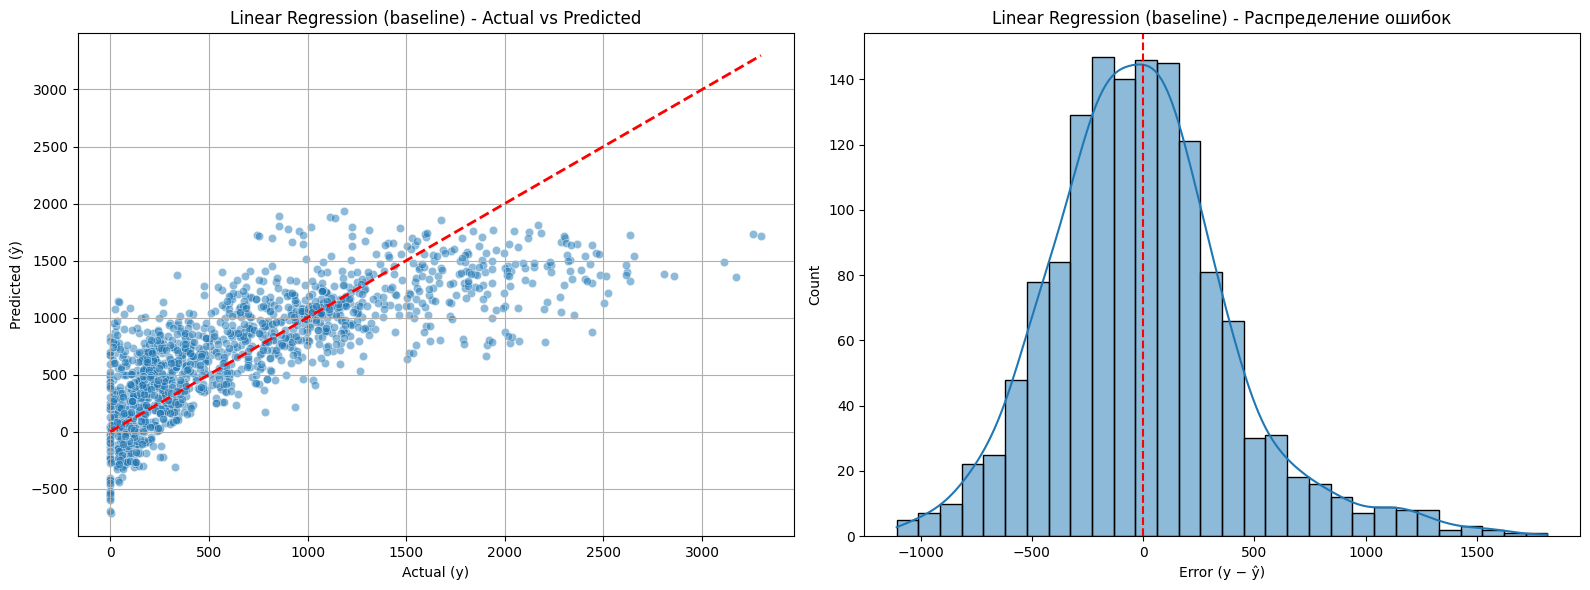

In [154]:
lr_metrics_df = show_metrics('Linear Regression (baseline)', baseline)

---

### EDA анализ

In [155]:
print("Явные дубликаты строк:", train.duplicated().sum())
train = train.drop_duplicates(keep='first')

Явные дубликаты строк: 0


In [156]:
num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['str']).columns
bool_cols = train.select_dtypes(include=['bool']).columns

In [157]:
df_eda = train.copy()

#### Анализ целевой переменной

In [158]:
rbc = df_eda['Rented Bike Count']

rbc.describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

In [159]:
def show_hist(data, name, xlabel='Признак'):    
    ax = data.plot(
        kind='hist',
        title=f'Распределение {name}',
        xlabel=xlabel,
        ylabel='Количетсво',
        rot=30,
        bins=20,
        figsize=(14, 4),
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
    plt.close()

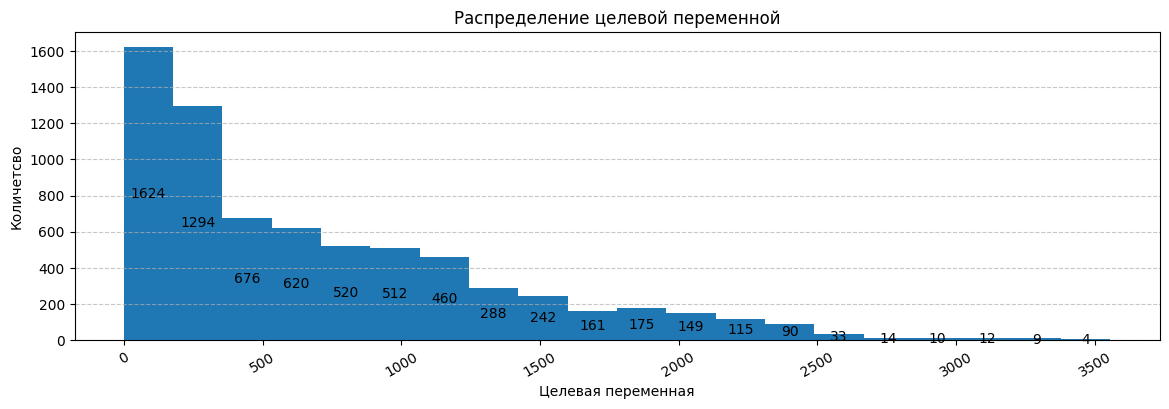

In [160]:
show_hist(rbc, 'целевой переменной', 'Целевая переменная')

#### Анализ числовых признаков

In [161]:
def check_num_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_num_features(df_eda, num_cols)

,Признак,Кол-во
0,Temperature,541
1,Humidity(%),87
2,Wind speed (m/s),64
3,Visibility (10m),1697
4,Dew point temperature,547
5,Solar Radiation (MJ/m2),344
6,Rainfall(mm),53
7,Snowfall (cm),47
8,Rented Bike Count,2024


In [162]:
def create_df_boxplot(data, ax):
    sns.boxplot(data=data, ax=ax)
    
    title = 'Размах значений признака'

    ax.set_title(title)
    ax.set_ylabel('Значение признака')

    ax.grid(True)
    ax.tick_params(axis='x', rotation=30)

In [163]:
def create_df_hist(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    
    hist.set_title(f'Распределение значений признака: {col}')
    hist.set_xlabel('Значение признака')
    hist.set_ylabel('Количество значений')
    hist.set_yscale('log')
    
    create_df_boxplot(data, axes[1])
    
    plt.show()
    plt.close()

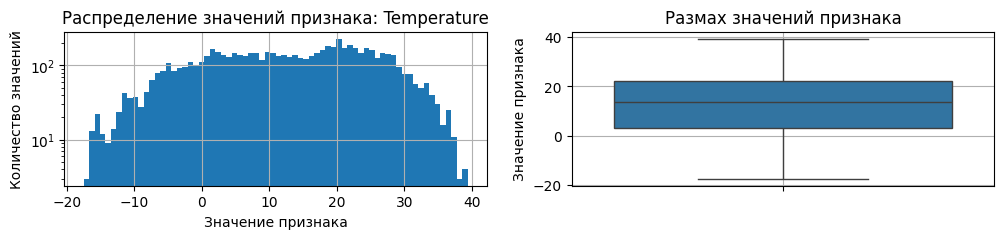

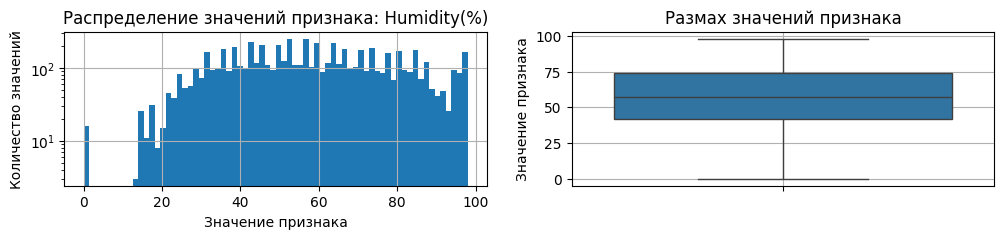

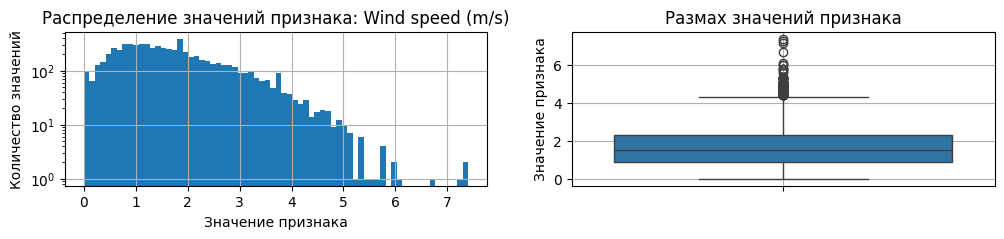

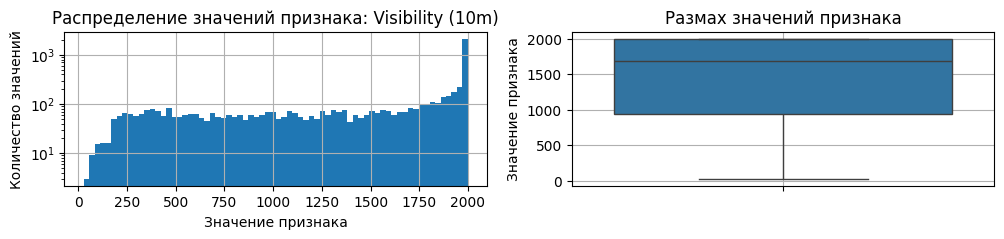

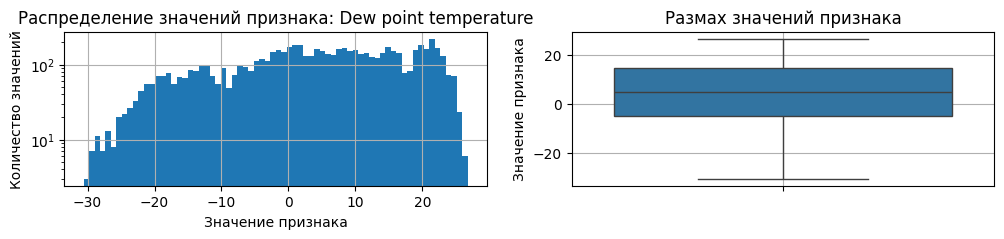

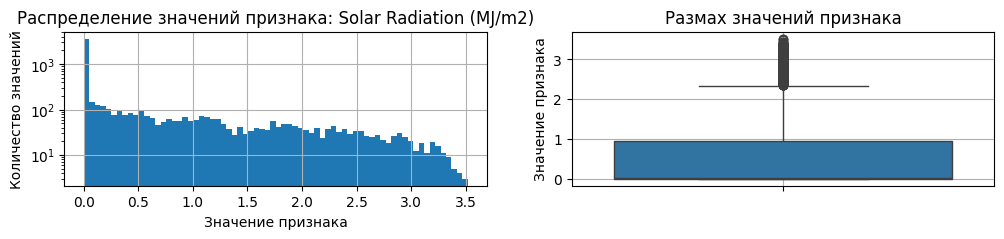

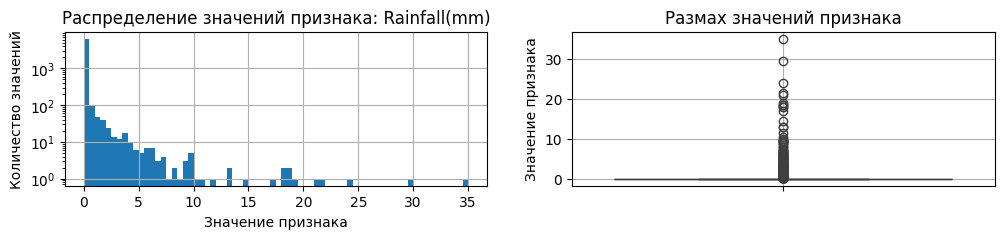

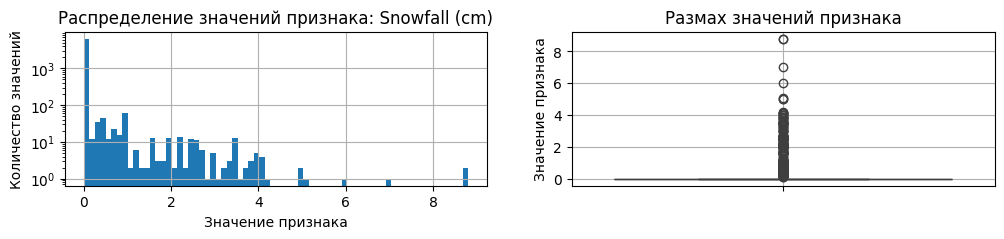

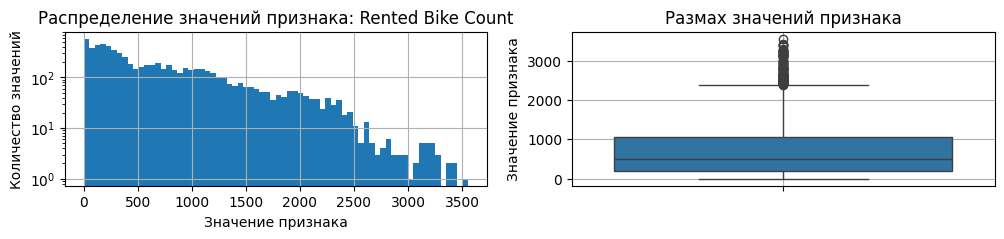

In [164]:
for col in num_cols:
    create_df_hist(df_eda[col], col)

#### Анализ категориальных и бинарных признаков

In [165]:
def check_cat_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_cat_features(df_eda, cat_cols)

,Признак,Уникальные значения,Кол-во
0,Seasons,"[Autumn, Winter, Summer, Spring]",4
1,Holiday,"[Holiday, No Holiday]",2
2,Functioning Day,"[Yes, No]",2


In [166]:
def show_countplot(df_eda, col):
    plt.figure(figsize=(12, 2)) 
    
    ax = sns.countplot(
        x=col,
        data=df_eda,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}')
    plt.xlabel('')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    
    plt.close()

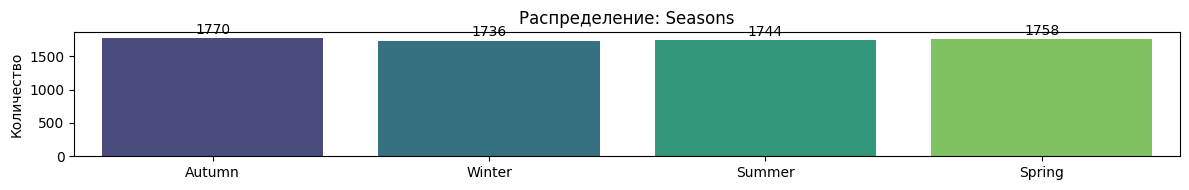

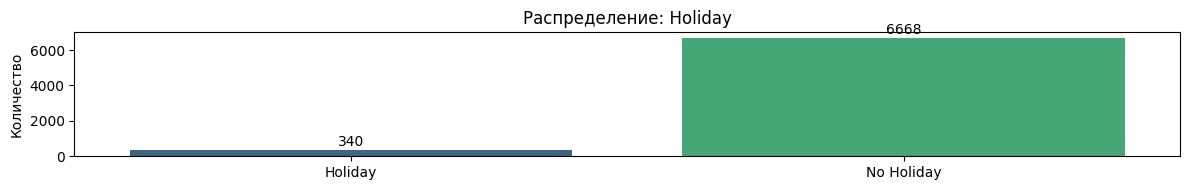

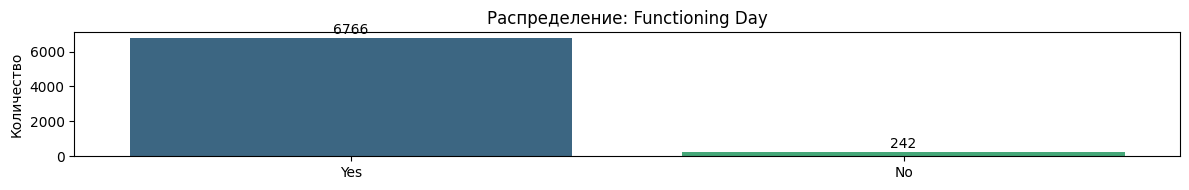

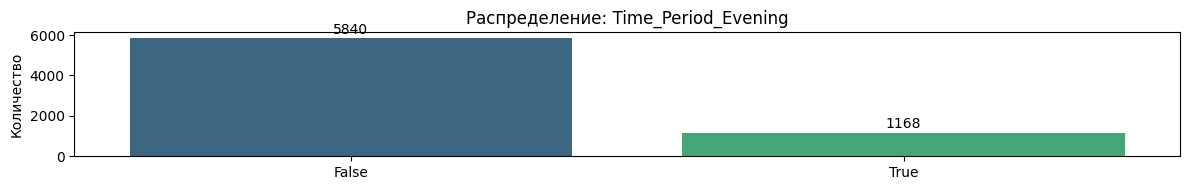

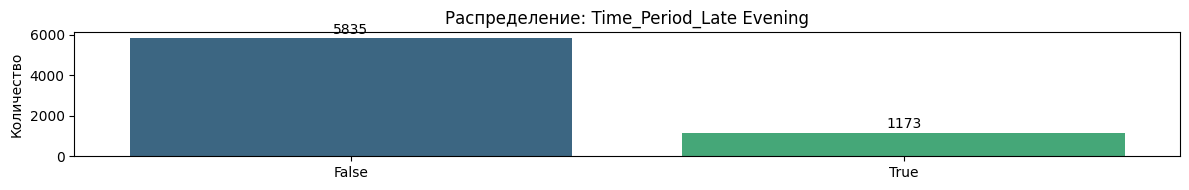

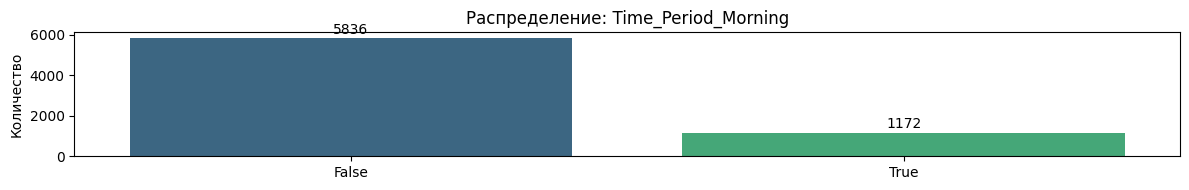

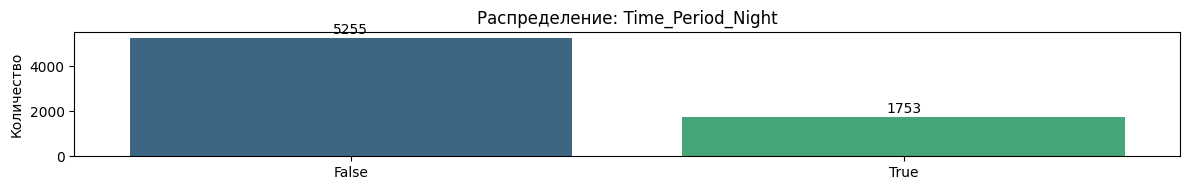

In [167]:
for col in cat_cols.append(bool_cols):
    show_countplot(df_eda, col)

#### Анализ и заполнение пропусков

In [168]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [169]:
show_missing_stats(df_eda)

,Кол-во пропусков,Доля пропусков
Snowfall (cm),263,3.75%
Rainfall(mm),262,3.74%
Visibility (10m),259,3.70%
Humidity(%),250,3.57%
Wind speed (m/s),210,3.00%
Solar Radiation (MJ/m2),210,3.00%


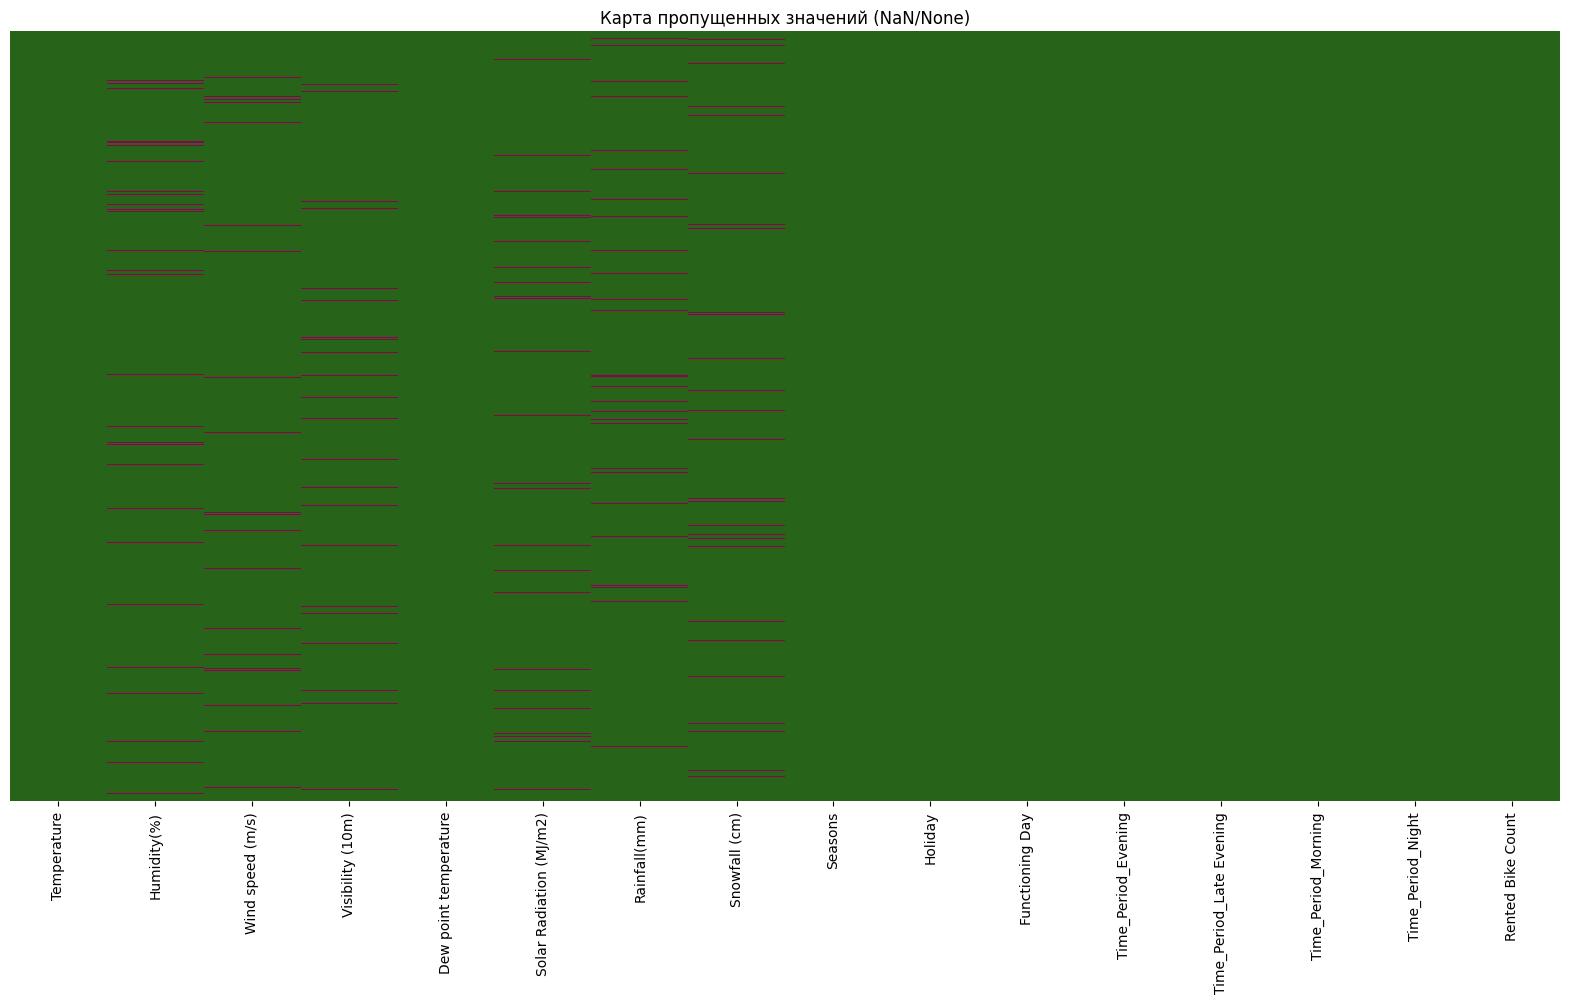

In [170]:
fig, ax = plt.subplots(figsize=(20,10)) 
sns.heatmap(df_eda.isna().astype(int), yticklabels=False, cbar=False, cmap='PiYG_r', xticklabels=df_eda.columns)

plt.title("Карта пропущенных значений (NaN/None)")
plt.show()

In [171]:
cols_to_fix = [
    'Snowfall (cm)', 'Rainfall(mm)', 'Visibility (10m)', 
    'Humidity(%)', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'
]

df_eda[cols_to_fix] = df_eda[cols_to_fix].fillna(df_eda[cols_to_fix].median())

In [172]:
show_missing_stats(df_eda)

'Пропусков в данных нет'

#### Анализ корреляций

In [173]:
def create_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef) 
    plt.figure(figsize=(x, dynamic_height)) 
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )
    
    plt.title(title)

    plt.show()

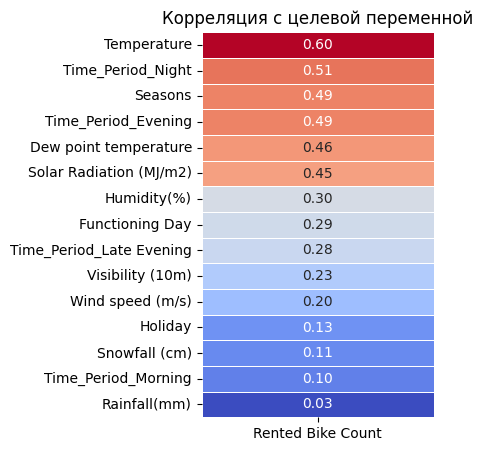

In [174]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

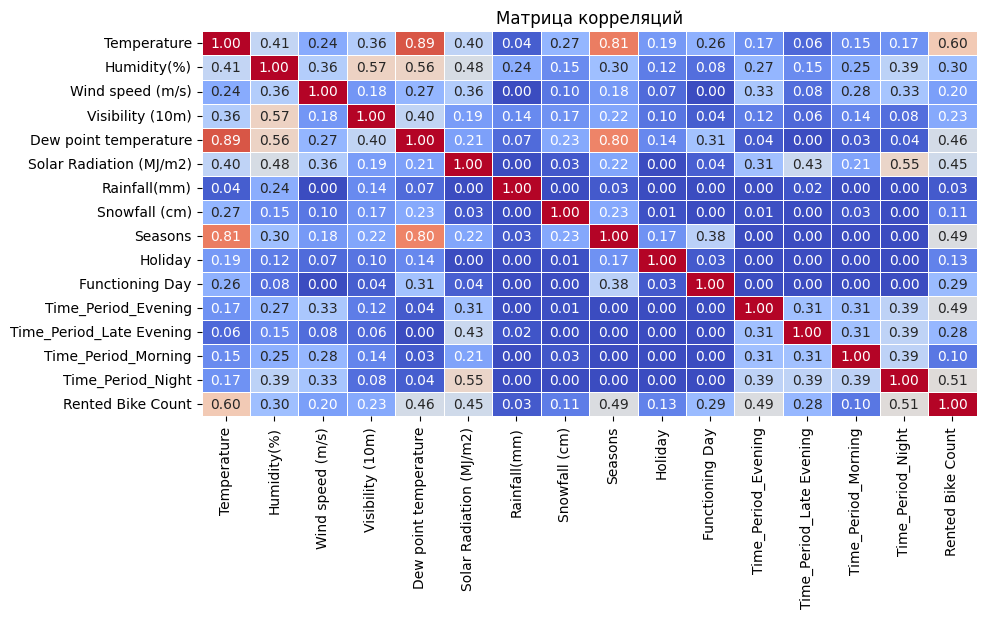

In [175]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

#### Создание полиномов

Для KNN моделей можно проделать логарифмирование, чтобы улучшить распределение и убрать хвосты на графиках.

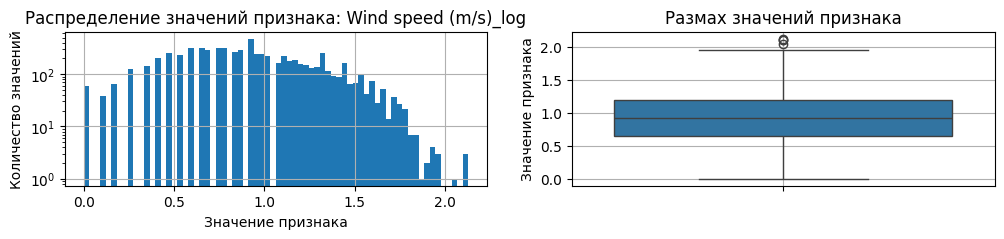

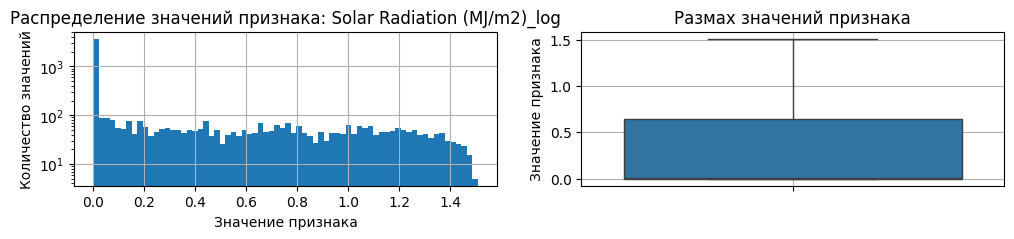

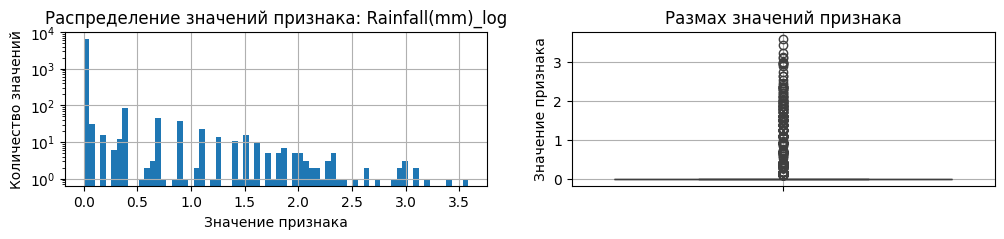

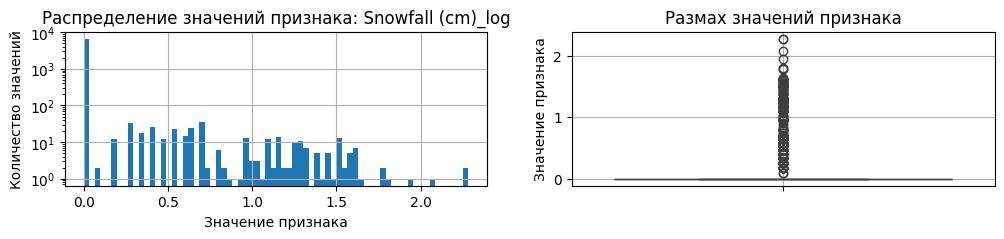

In [176]:
features_with_tails = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
log_col_names = [f'{col}_log' for col in features_with_tails]
df_eda[log_col_names] = df_eda[features_with_tails].apply(np.log1p)

for col in log_col_names:
    create_df_hist(df_eda[col], col)

Для признаков Rainfall и Snowfall логарифмирование не улучшило распределение - удалим признаки _log, но признаки стоит доработать, чтобы модели было проще работать с ними. Стоит преобразовать в категории.

In [177]:
df_eda = df_eda.drop(columns=['Rainfall(mm)_log', 'Snowfall (cm)_log', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'])

#### Создание категориальных признаков

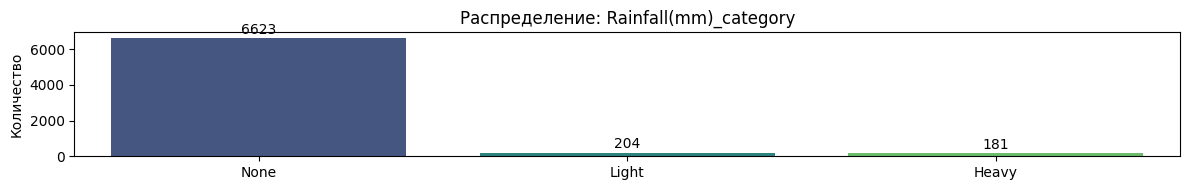

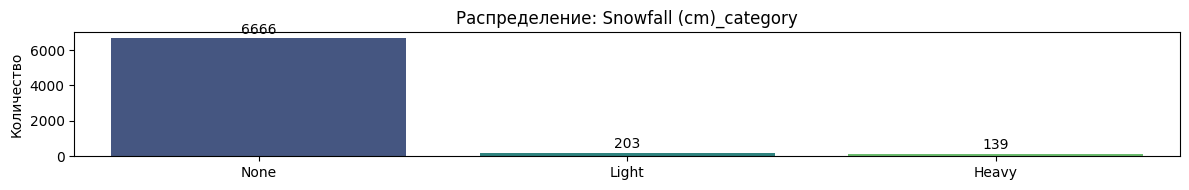

In [178]:
for col in ['Rainfall(mm)', 'Snowfall (cm)']:
    new_col = f"{col}_category"

    df_eda[new_col] = pd.cut(df_eda[col], 
                             bins=[-np.inf, 0, 1, np.inf], 
                             labels=['None', 'Light', 'Heavy'])
    
    df_eda = df_eda.drop(columns=[col])
    
    show_countplot(df_eda, new_col)

#### Повторный анализ корреляции

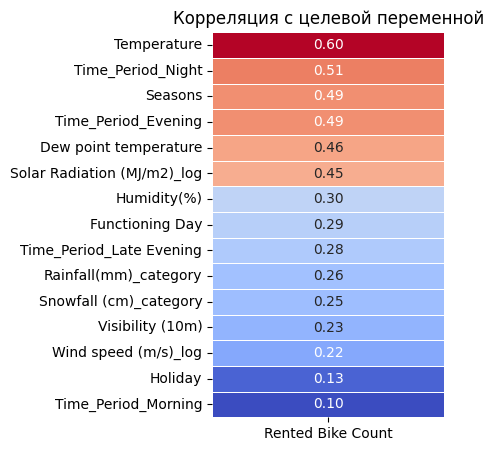

In [179]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rented Bike Count', 'Wind speed (m/s)_log', 'Solar Radiation (MJ/m2)_log'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

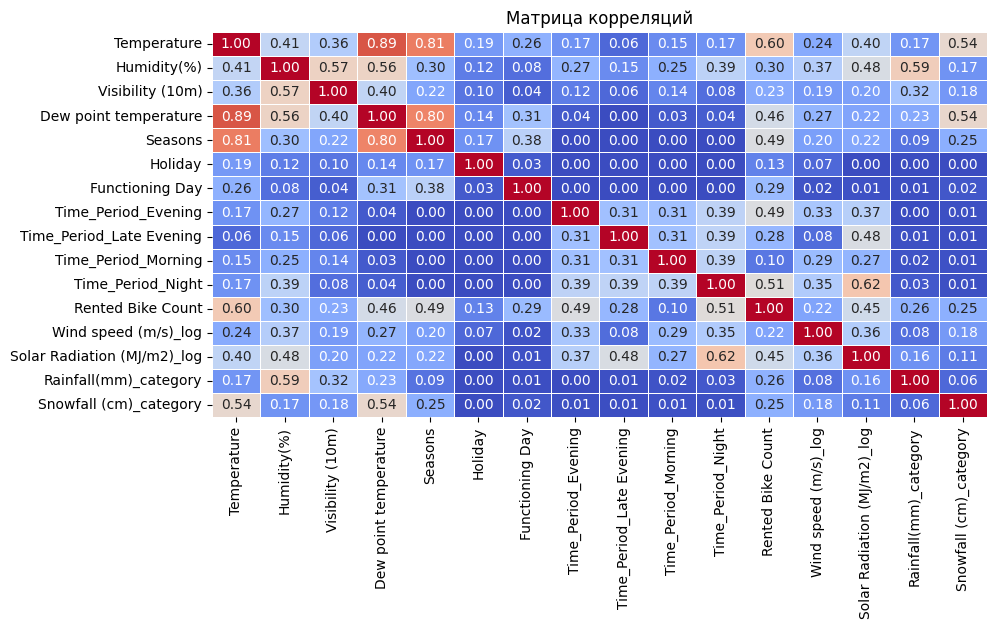

In [180]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Для KNN важно избавиться от корреляции между признаками, поэтому данные столбцы не будут удалены сразу, а только при обучении моделей KNN. Оставить стоит только Temperature, так как данный признак имеет наибольшую корреляция с таргетом. Удаляться будут: 'Seasons', 'Dew point temperature'.

Вывод: обработаны пропуски в погодных числовых признаках (~3–3.75%) заполнением медианой, изучено распределение таргета (правосторонняя асимметрия с "хвостом") и корреляции. Для KNN рассмотрены преобразования: логарифмирование, при этом для Rainfall/Snowfall оно не помогло - признаки планируются к категоризации; также для снижения мультиколлинеарности в KNN-ветке оставляется Temperature, а Seasons и Dew point temperature исключаются. Дополнительно добавлены полиномиальные признаки и новые категории из числовых признаков, что улучшило корреляции и позволило лучше учитывать нелинейные зависимости.

---

### Обучение моделей

#### Создание KNN моделей

In [181]:
target = ['Rented Bike Count']
correlating_features = ['Seasons', 'Dew point temperature']

log_features = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)']
fall_features = ['Rainfall(mm)', 'Snowfall (cm)']

In [182]:
num_cols = [col for col in num_cols if col not in target]
cat_cols = [col for col in cat_cols if col not in target]
bool_cols = [col for col in bool_cols if col not in target]

In [183]:
knn_num_cols = [col for col in num_cols if col not in correlating_features + log_features + fall_features]
knn_cat_cols = [col for col in cat_cols if col not in correlating_features]
knn_bool_cols = [col for col in bool_cols if col not in correlating_features]

In [184]:
def bool_to_int(df):
    return df.astype(int)

In [185]:
def fall_binning(X):
    X_df = X.copy()
    for col in X_df.columns:
        X_df[col] = pd.cut(
            X_df[col], 
            bins=[-np.inf, 0, 1, np.inf], 
            labels=['None', 'Light', 'Heavy'],
        )
    return X_df

def get_fall_feature_names(transformer, input_features):
    return input_features 

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('log', make_pipeline(
                SimpleImputer(strategy='constant', fill_value=0),
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                StandardScaler()
        ), log_features),
        
        ('num', make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ), knn_num_cols),
        
        ('fall', make_pipeline(
            FunctionTransformer(fall_binning, feature_names_out=get_fall_feature_names),
            OneHotEncoder(drop='first', sparse_output=False),
        ), fall_features),
        
        ('cat', OneHotEncoder(drop='first', sparse_output=False), knn_cat_cols),
        
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), knn_bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [186]:
X_transformed_df = knn_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,log__Wind speed (m/s),log__Solar Radiation (MJ/m2),num__Temperature,num__Humidity(%),num__Visibility (10m),fall__Rainfall(mm)_Light,fall__Rainfall(mm)_None,fall__Rainfall(mm)_nan,fall__Snowfall (cm)_Light,fall__Snowfall (cm)_None,fall__Snowfall (cm)_nan,cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
1741,1.550504,-0.726497,0.527944,0.192249,0.521845,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
3105,0.027521,-0.726497,-0.294434,-0.307843,0.929214,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
1869,-0.657927,-0.726497,-1.544783,1.542495,-1.801669,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0,1,0
4643,0.219743,1.246250,0.720951,0.642331,-1.625645,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,0
387,0.310577,-0.726497,0.402070,-0.057797,-0.842759,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,1


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),KNN (baseline),340.59,233.00,0.72,33.06
1,Test,KNN (baseline),359.30,243.87,0.69,34.46


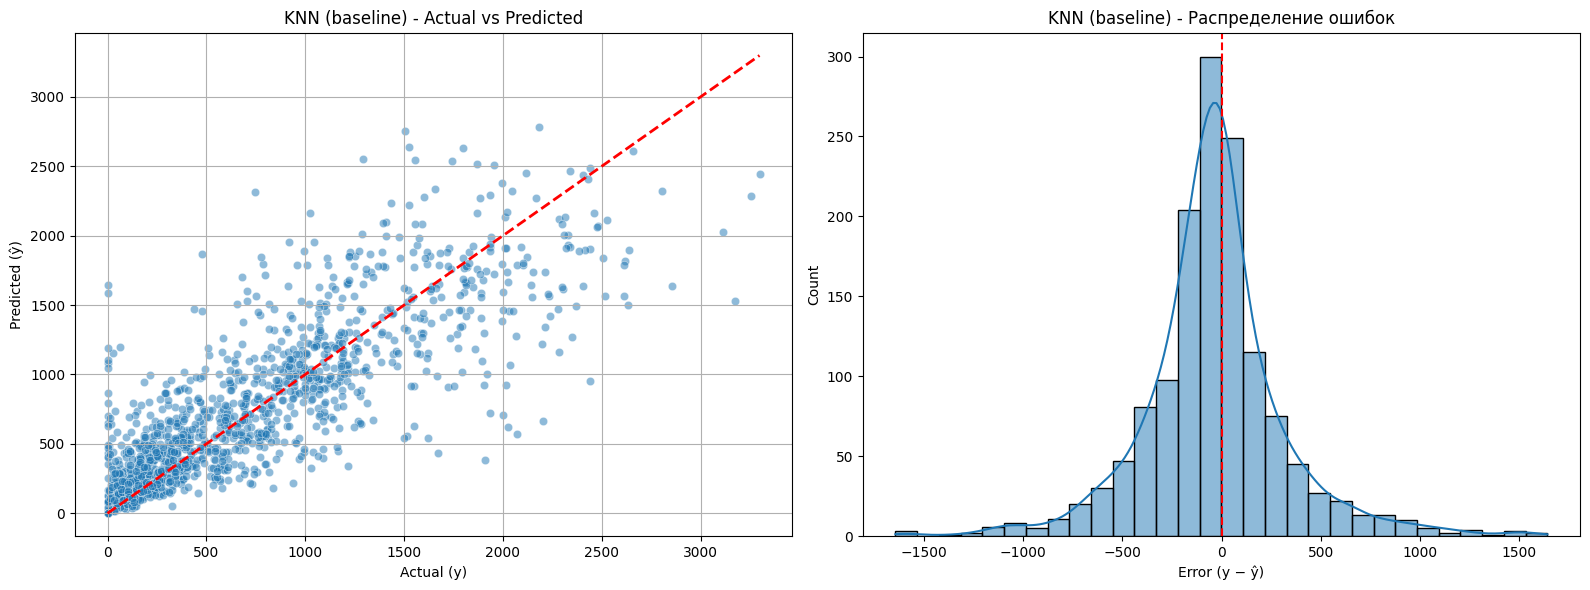

In [187]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),
    ('model', KNeighborsRegressor())
])

knn_baseline_metrics_df = show_metrics('KNN (baseline)', knn_pipeline)

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),KNN (filted),327.06,219.1,0.74,31.08
1,Test,KNN (filted),334.61,222.3,0.73,31.41


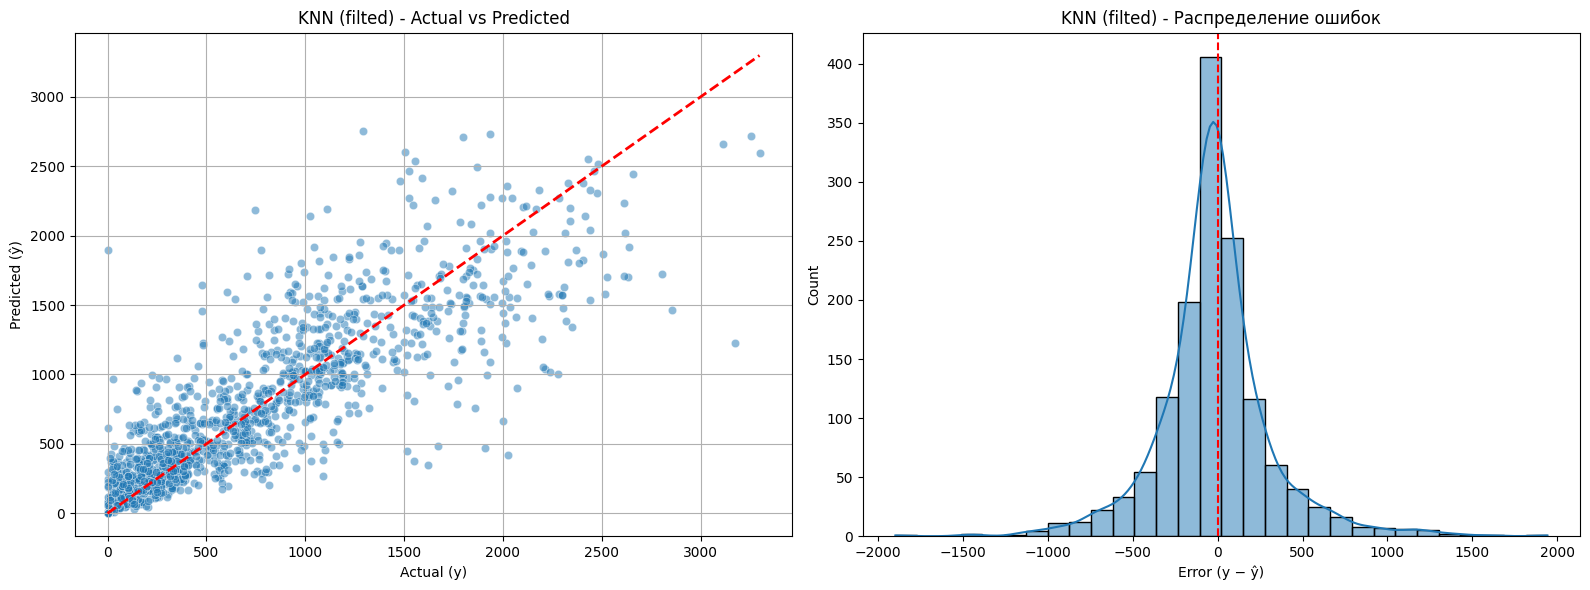

In [188]:
rf_estimator = Ridge(random_state=RANDOM_STATE)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),

    ('var_thresh', VarianceThreshold(threshold=0.001)),
    ('correlation_filter', SelectKBest(score_func=f_regression, k='all')),
    ('rfe', RFE(estimator=rf_estimator, n_features_to_select=.8, step=2)),

    ('model', KNeighborsRegressor())
])

knn_filted_metrics_df = show_metrics('KNN (filted)', knn_pipeline)

In [189]:
def objective(trial):
    params = {
        "n_neighbors": trial.suggest_int('n_neighbors', 2, 100),
        "weights": trial.suggest_categorical('weights', ['uniform', 'distance']),
        "p": trial.suggest_int('p', 1, 6)
    }

    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)

    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )
    
    mean_score = scores.mean()

    trial.report(mean_score, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

knn_best_params = study.best_params
print("Лучшие гиперпараметры:", knn_best_params)
knn_best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(knn_best_value, 3))

[I 2026-02-13 16:48:45,698] A new study created in memory with name: no-name-6dbe91e9-1df0-48a5-b792-d2eccbe0288d
Best trial: 2. Best value: 351.384:   1%|          | 1/100 [00:00<00:58,  1.69it/s]

[I 2026-02-13 16:48:46,284] Trial 2 finished with value: 351.3843264146664 and parameters: {'n_neighbors': 31, 'weights': 'uniform', 'p': 1}. Best is trial 2 with value: 351.3843264146664.


Best trial: 2. Best value: 351.384:   4%|▍         | 4/100 [00:00<00:17,  5.40it/s]

[I 2026-02-13 16:48:46,520] Trial 0 finished with value: 375.79816203052644 and parameters: {'n_neighbors': 36, 'weights': 'uniform', 'p': 6}. Best is trial 2 with value: 351.3843264146664.
[I 2026-02-13 16:48:46,611] Trial 1 finished with value: 377.16003619930336 and parameters: {'n_neighbors': 79, 'weights': 'distance', 'p': 3}. Best is trial 2 with value: 351.3843264146664.
[I 2026-02-13 16:48:46,660] Trial 3 finished with value: 400.3378301550248 and parameters: {'n_neighbors': 87, 'weights': 'uniform', 'p': 6}. Best is trial 2 with value: 351.3843264146664.


Best trial: 7. Best value: 334.833:   7%|▋         | 7/100 [00:01<00:17,  5.25it/s]

...

Best trial: 35. Best value: 329.053:  96%|█████████▌| 96/100 [00:12<00:00, 11.23it/s]

[I 2026-02-13 16:48:58,283] Trial 94 finished with value: 332.2253641515859 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 1}. Best is trial 35 with value: 329.05264490385025.
[I 2026-02-13 16:48:58,305] Trial 95 finished with value: 332.2253641515859 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 1}. Best is trial 35 with value: 329.05264490385025.
[I 2026-02-13 16:48:58,413] Trial 96 pruned. 


Best trial: 35. Best value: 329.053: 100%|██████████| 100/100 [00:12<00:00,  7.76it/s]


[I 2026-02-13 16:48:58,495] Trial 97 finished with value: 331.3817349891762 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 1}. Best is trial 35 with value: 329.05264490385025.
[I 2026-02-13 16:48:58,569] Trial 98 pruned. 
[I 2026-02-13 16:48:58,580] Trial 99 finished with value: 329.5284555772936 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 1}. Best is trial 35 with value: 329.05264490385025.


Лучшие гиперпараметры: {'n_neighbors': 10, 'weights': 'distance', 'p': 1}
Лучшее среднее значение RMSE на кросс-валидации: 329.053


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),KNN (best params),329.05,227.63,0.74,32.30
1,Test,KNN (best params),340.24,231.98,0.72,32.78


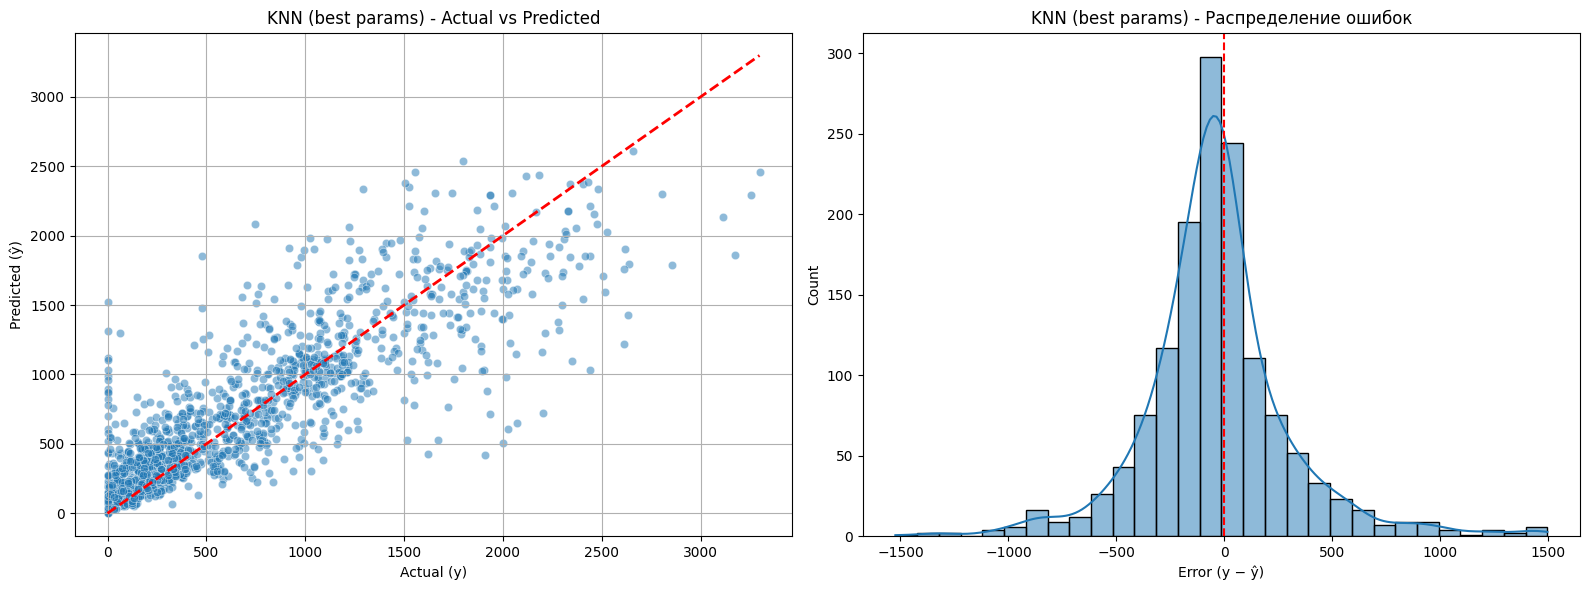

In [190]:
model = KNeighborsRegressor(**study.best_params)
knn_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("model", model)
])

knn_best_metrics_df = show_metrics('KNN (best params)', knn_pipeline)

---

#### Создание деревьев

In [191]:
def show_tree_plot(name, pipeline):
    tree_model = pipeline.named_steps["model"]
    preprocessor = pipeline.named_steps["preprocessor"]

    feature_names = preprocessor.get_feature_names_out()

    _, ax = plt.subplots(1, 1, figsize=(26, 12))
    plot_tree(
        tree_model,
        ax=ax,
        filled=True,
        rounded=True,
        feature_names=feature_names,
        fontsize=12,
        max_depth=3,
        impurity=False,
        precision=2 
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

In [192]:
def show_feature_importance(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    feature_importance = pd.DataFrame(
        {
            "feature": preprocessor.get_feature_names_out(),
            "importance": model.feature_importances_ * 100,
        }
    ).sort_values("importance", ascending=False)

    display(feature_importance \
            .style.format({'importance': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm'))
    
    top_5_feature_names = feature_importance['feature'].values[:5]
    top_5_feature_importance = feature_importance['importance'].values[:5]

    plt.figure(figsize=(8, 5))
    plt.barh(top_5_feature_names, top_5_feature_importance, color='lightseagreen')
    plt.xlabel('Важность признака')
    plt.title('Важность признаков в дереве решений')
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

In [193]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [194]:
X_transformed_df = tree_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,num__Temperature,num__Humidity(%),num__Wind speed (m/s),num__Visibility (10m),num__Dew point temperature,num__Solar Radiation (MJ/m2),num__Rainfall(mm),num__Snowfall (cm),cat__Seasons_Spring,cat__Seasons_Summer,cat__Seasons_Winter,cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
1741,19.1,62.0,3.6,1757.0,11.6,0.01,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0,1,0,0
3105,9.3,52.0,1.5,2000.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,1,0,0
1869,-5.6,89.0,0.9,371.0,-7.1,0.00,0.0,2.2,0.0,0.0,1.0,1.0,1.0,0,0,1,0
4643,21.4,71.0,1.7,476.0,15.9,1.43,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0,0,0,0
387,17.6,57.0,1.8,943.0,8.9,0.00,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0,0,0,1


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Decision Tree Regressor (baseline),391.75,249.61,0.63,35.40
1,Test,Decision Tree Regressor (baseline),383.64,242.55,0.64,34.28


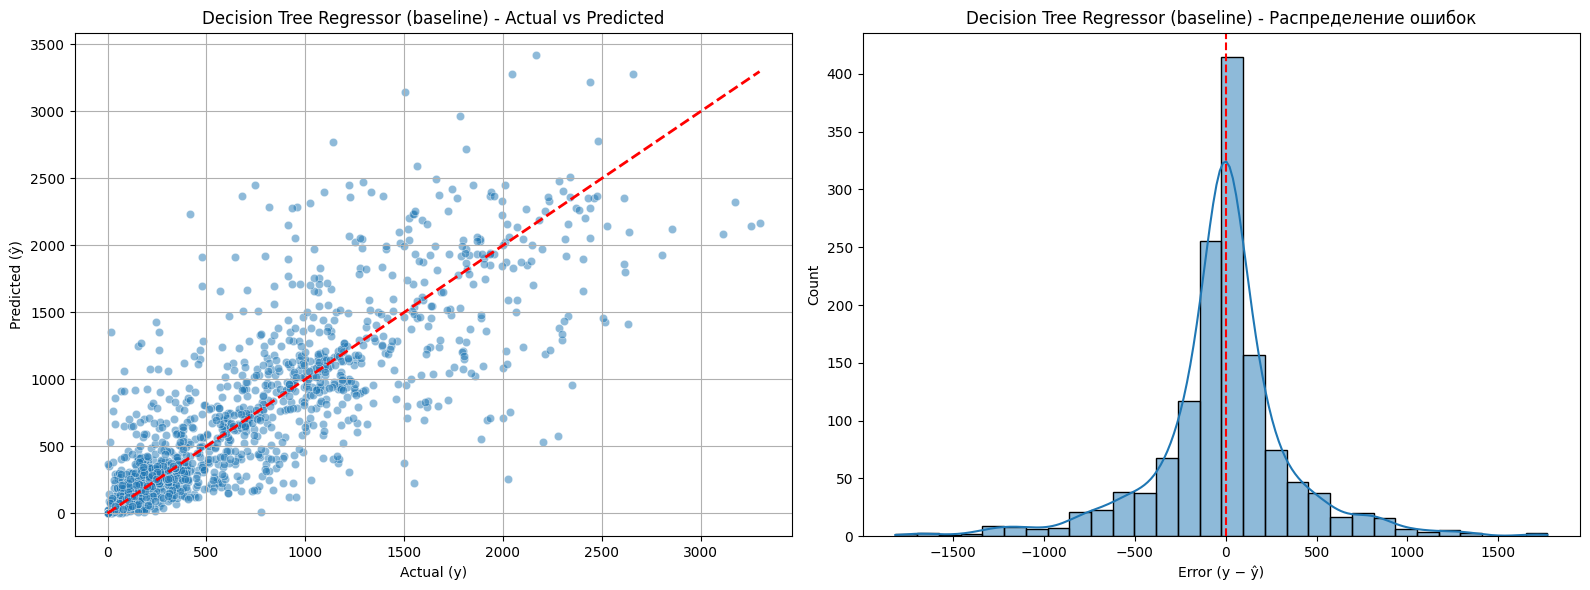

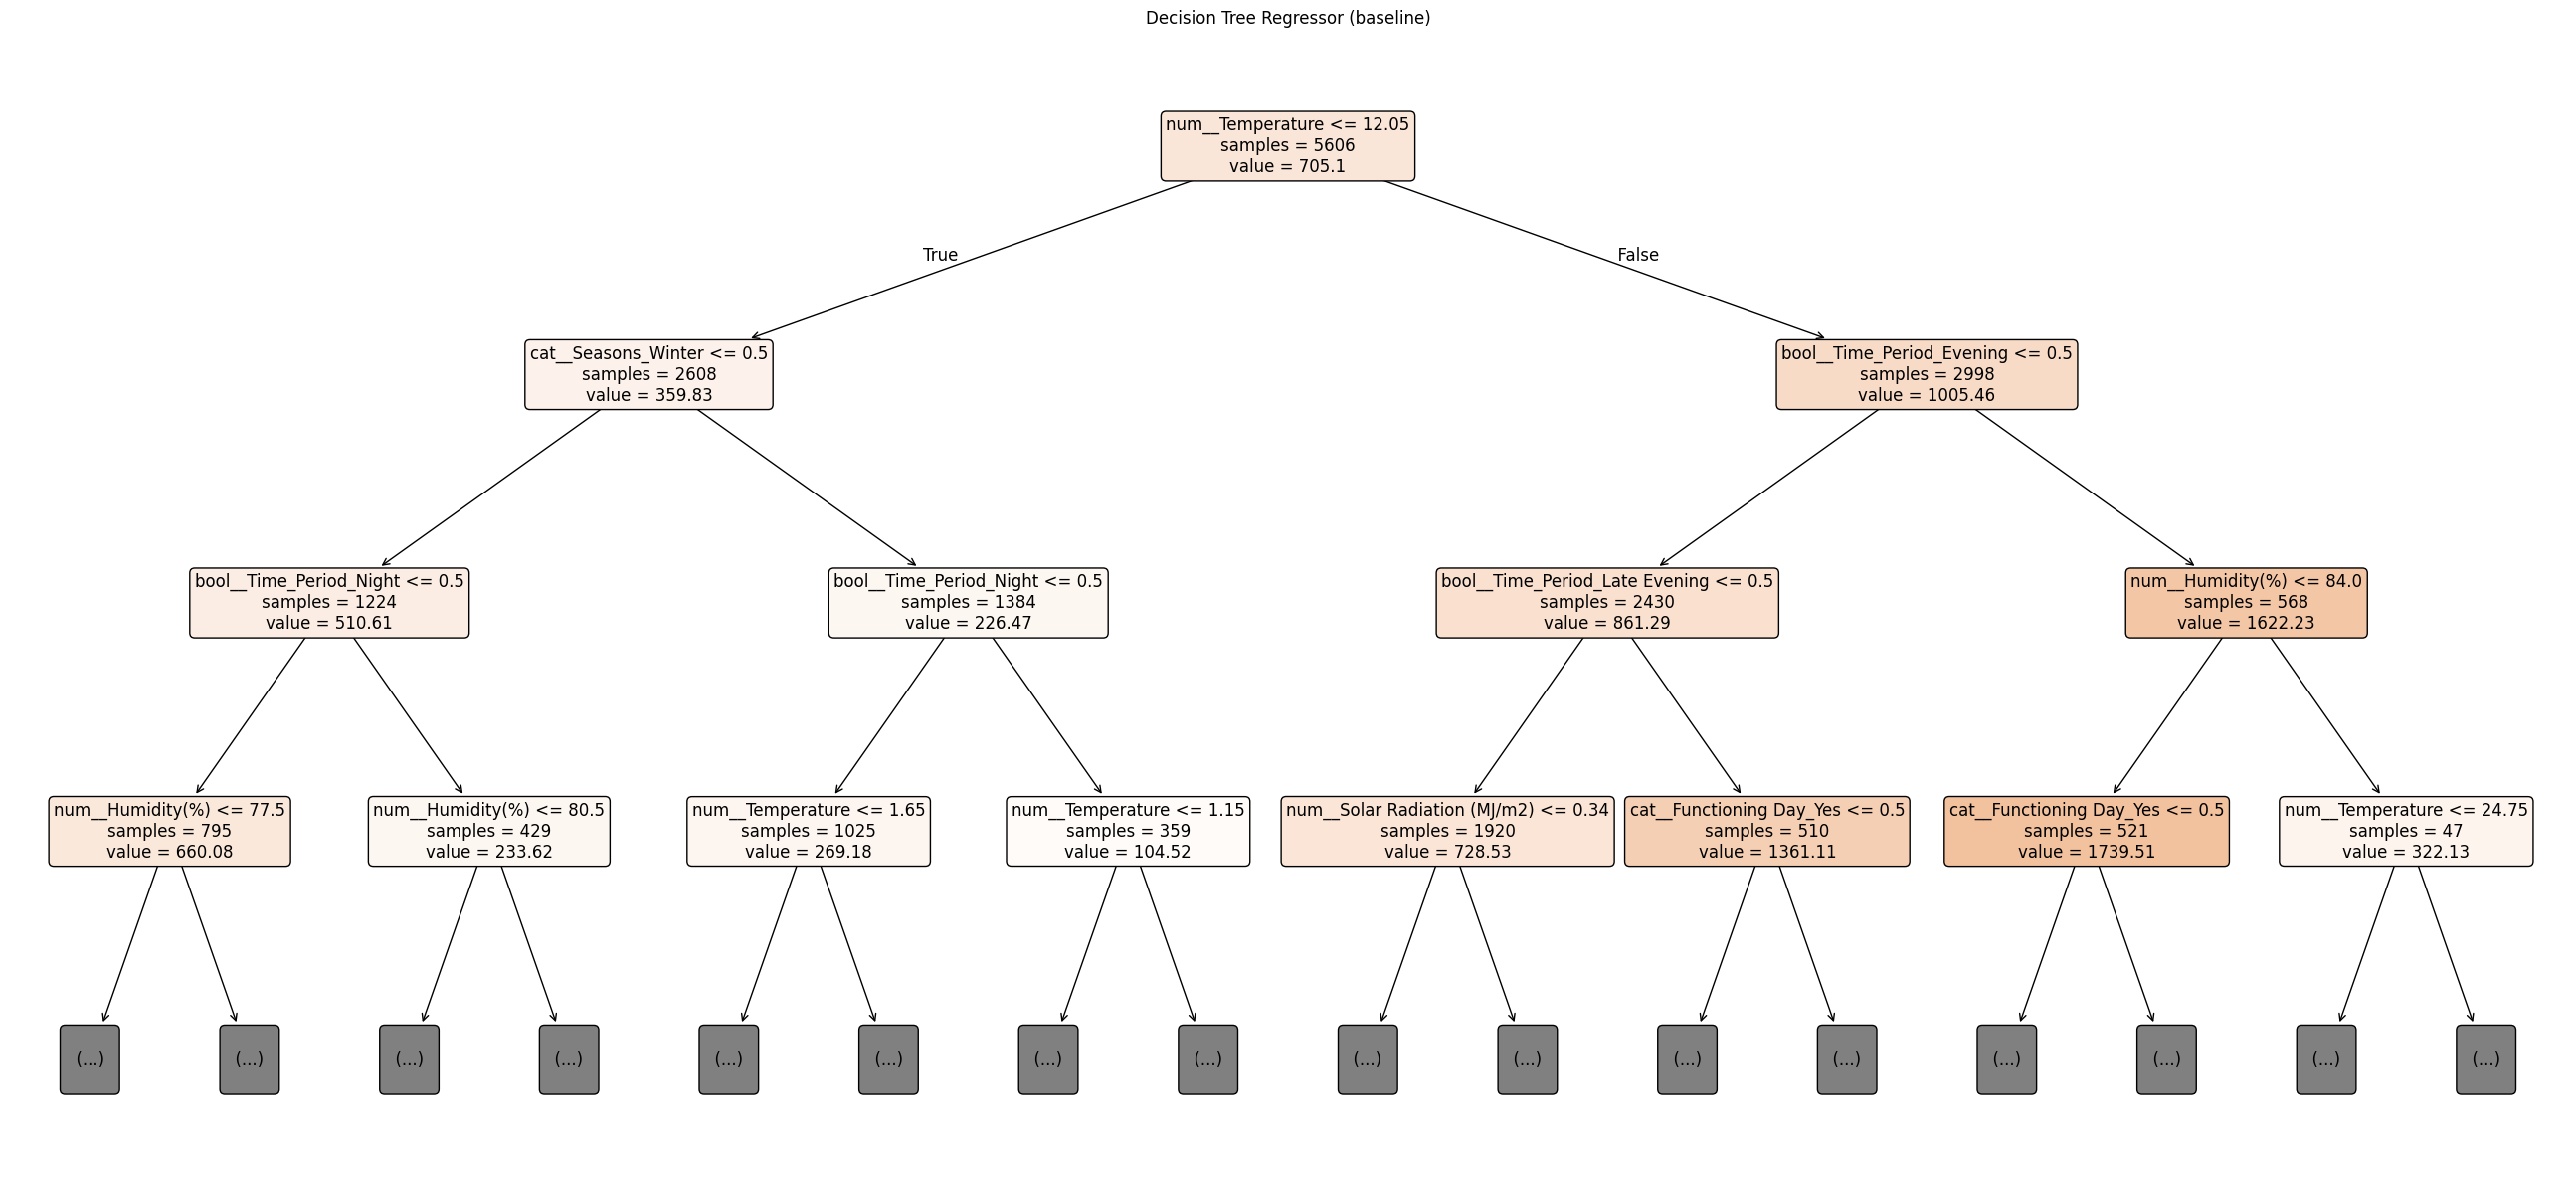

,feature,importance
0,num__Temperature,32.19%
13,bool__Time_Period_Evening,11.75%
5,num__Solar Radiation (MJ/m2),10.03%
1,num__Humidity(%),9.09%
12,cat__Functioning Day_Yes,8.97%
14,bool__Time_Period_Late Evening,6.89%
4,num__Dew point temperature,4.76%
6,num__Rainfall(mm),3.63%
2,num__Wind speed (m/s),3.00%
3,num__Visibility (10m),2.82%


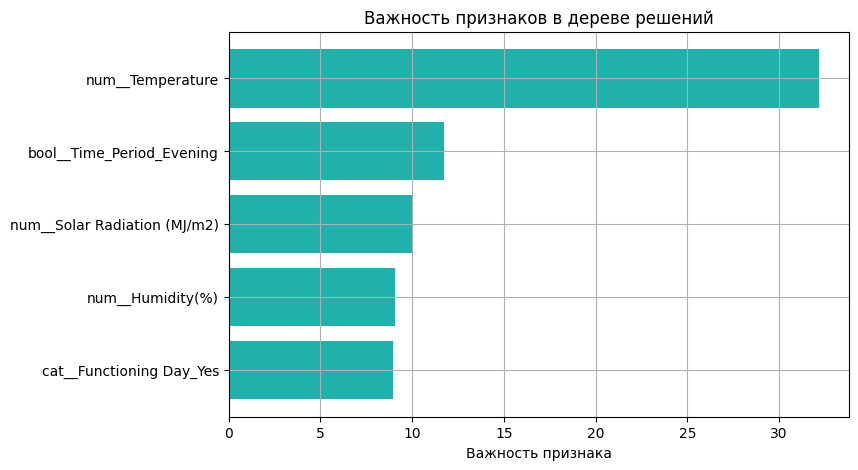

In [195]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

name = 'Decision Tree Regressor (baseline)'
dtr_baseline_metrics_df = show_metrics(name, tree_pipeline)
show_tree_plot(name, tree_pipeline)
show_feature_importance(tree_pipeline)

In [196]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 2, 100),  
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error"])
    }

    model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)
    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    mean_score = scores.mean()

    trial.report(mean_score, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

tree_best_params = study.best_params
print("Лучшие гиперпараметры:", tree_best_params)
tree_best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(tree_best_value, 3))

[I 2026-02-13 16:48:59,455] A new study created in memory with name: no-name-4e9ce1a3-5e72-4aa1-92ef-ac0fee971692
Best trial: 2. Best value: 322.054:   1%|          | 1/100 [00:00<00:10,  9.35it/s]

[I 2026-02-13 16:48:59,561] Trial 2 finished with value: 322.0541553548853 and parameters: {'max_depth': 44, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_leaf_nodes': 55, 'ccp_alpha': 0.0925697326975267, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 2 with value: 322.0541553548853.


Best trial: 2. Best value: 322.054:   5%|▌         | 5/100 [00:00<00:12,  7.32it/s]

[I 2026-02-13 16:48:59,950] Trial 3 finished with value: 487.8809476911718 and parameters: {'max_depth': 50, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_leaf_nodes': 6, 'ccp_alpha': 0.00686049356642372, 'max_features': 'log2', 'criterion': 'absolute_error'}. Best is trial 2 with value: 322.0541553548853.
[I 2026-02-13 16:49:00,017] Trial 0 finished with value: 420.3779898516949 and parameters: {'max_depth': 49, 'min_samples_split': 3, 'min_samples_leaf': 14, 'max_leaf_nodes': 18, 'ccp_alpha': 0.041714507235714064, 'max_features': 'log2', 'criterion': 'absolute_error'}. Best is trial 2 with value: 322.0541553548853.
[I 2026-02-13 16:49:00,060] Trial 1 finished with value: 383.9738516076444 and parameters: {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_leaf_nodes': 70, 'ccp_alpha': 0.07932600378715417, 'max_features': 'log2', 'criterion': 'absolute_error'}. Best is trial 2 with value: 322.0541553548853.
[I 2026-02-13 16:49:00,098] Trial 6 finished with val

Best trial: 2. Best value: 322.054:   8%|▊         | 8/100 [00:00<00:06, 14.48it/s]

...

Best trial: 53. Best value: 319.594:  97%|█████████▋| 97/100 [00:06<00:00, 22.28it/s]

[I 2026-02-13 16:49:06,219] Trial 93 pruned. 
[I 2026-02-13 16:49:06,229] Trial 92 finished with value: 322.0576512844139 and parameters: {'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_leaf_nodes': 91, 'ccp_alpha': 0.021295818794450874, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 53 with value: 319.5935883304017.
[I 2026-02-13 16:49:06,269] Trial 94 finished with value: 321.7602109116931 and parameters: {'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_leaf_nodes': 92, 'ccp_alpha': 0.022946004687524793, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 53 with value: 319.5935883304017.
[I 2026-02-13 16:49:06,331] Trial 95 finished with value: 321.33351266303634 and parameters: {'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 17, 'max_leaf_nodes': 88, 'ccp_alpha': 0.018835135741471717, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 53 with value: 319.5935883304017.
[I 20

Best trial: 53. Best value: 319.594: 100%|██████████| 100/100 [00:07<00:00, 14.26it/s]


[I 2026-02-13 16:49:06,445] Trial 98 pruned. 
[I 2026-02-13 16:49:06,466] Trial 99 finished with value: 321.0743444150956 and parameters: {'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 17, 'max_leaf_nodes': 86, 'ccp_alpha': 0.024776224083225218, 'max_features': None, 'criterion': 'squared_error'}. Best is trial 53 with value: 319.5935883304017.


Лучшие гиперпараметры: {'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_leaf_nodes': 58, 'ccp_alpha': 0.0018642610078752429, 'max_features': None, 'criterion': 'squared_error'}
Лучшее среднее значение RMSE на кросс-валидации: 319.594


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Decision Tree Regressor (best params),319.59,216.58,0.76,30.73
1,Test,Decision Tree Regressor (best params),327.42,221.62,0.74,31.32


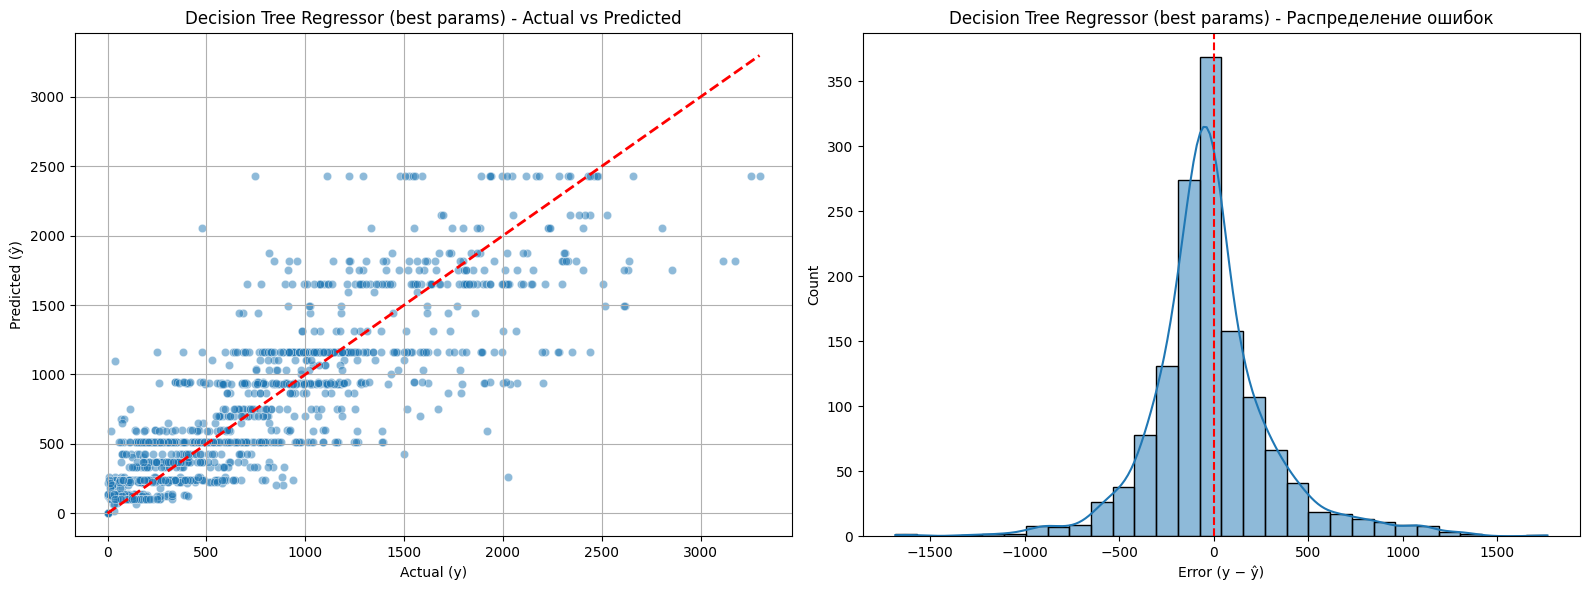

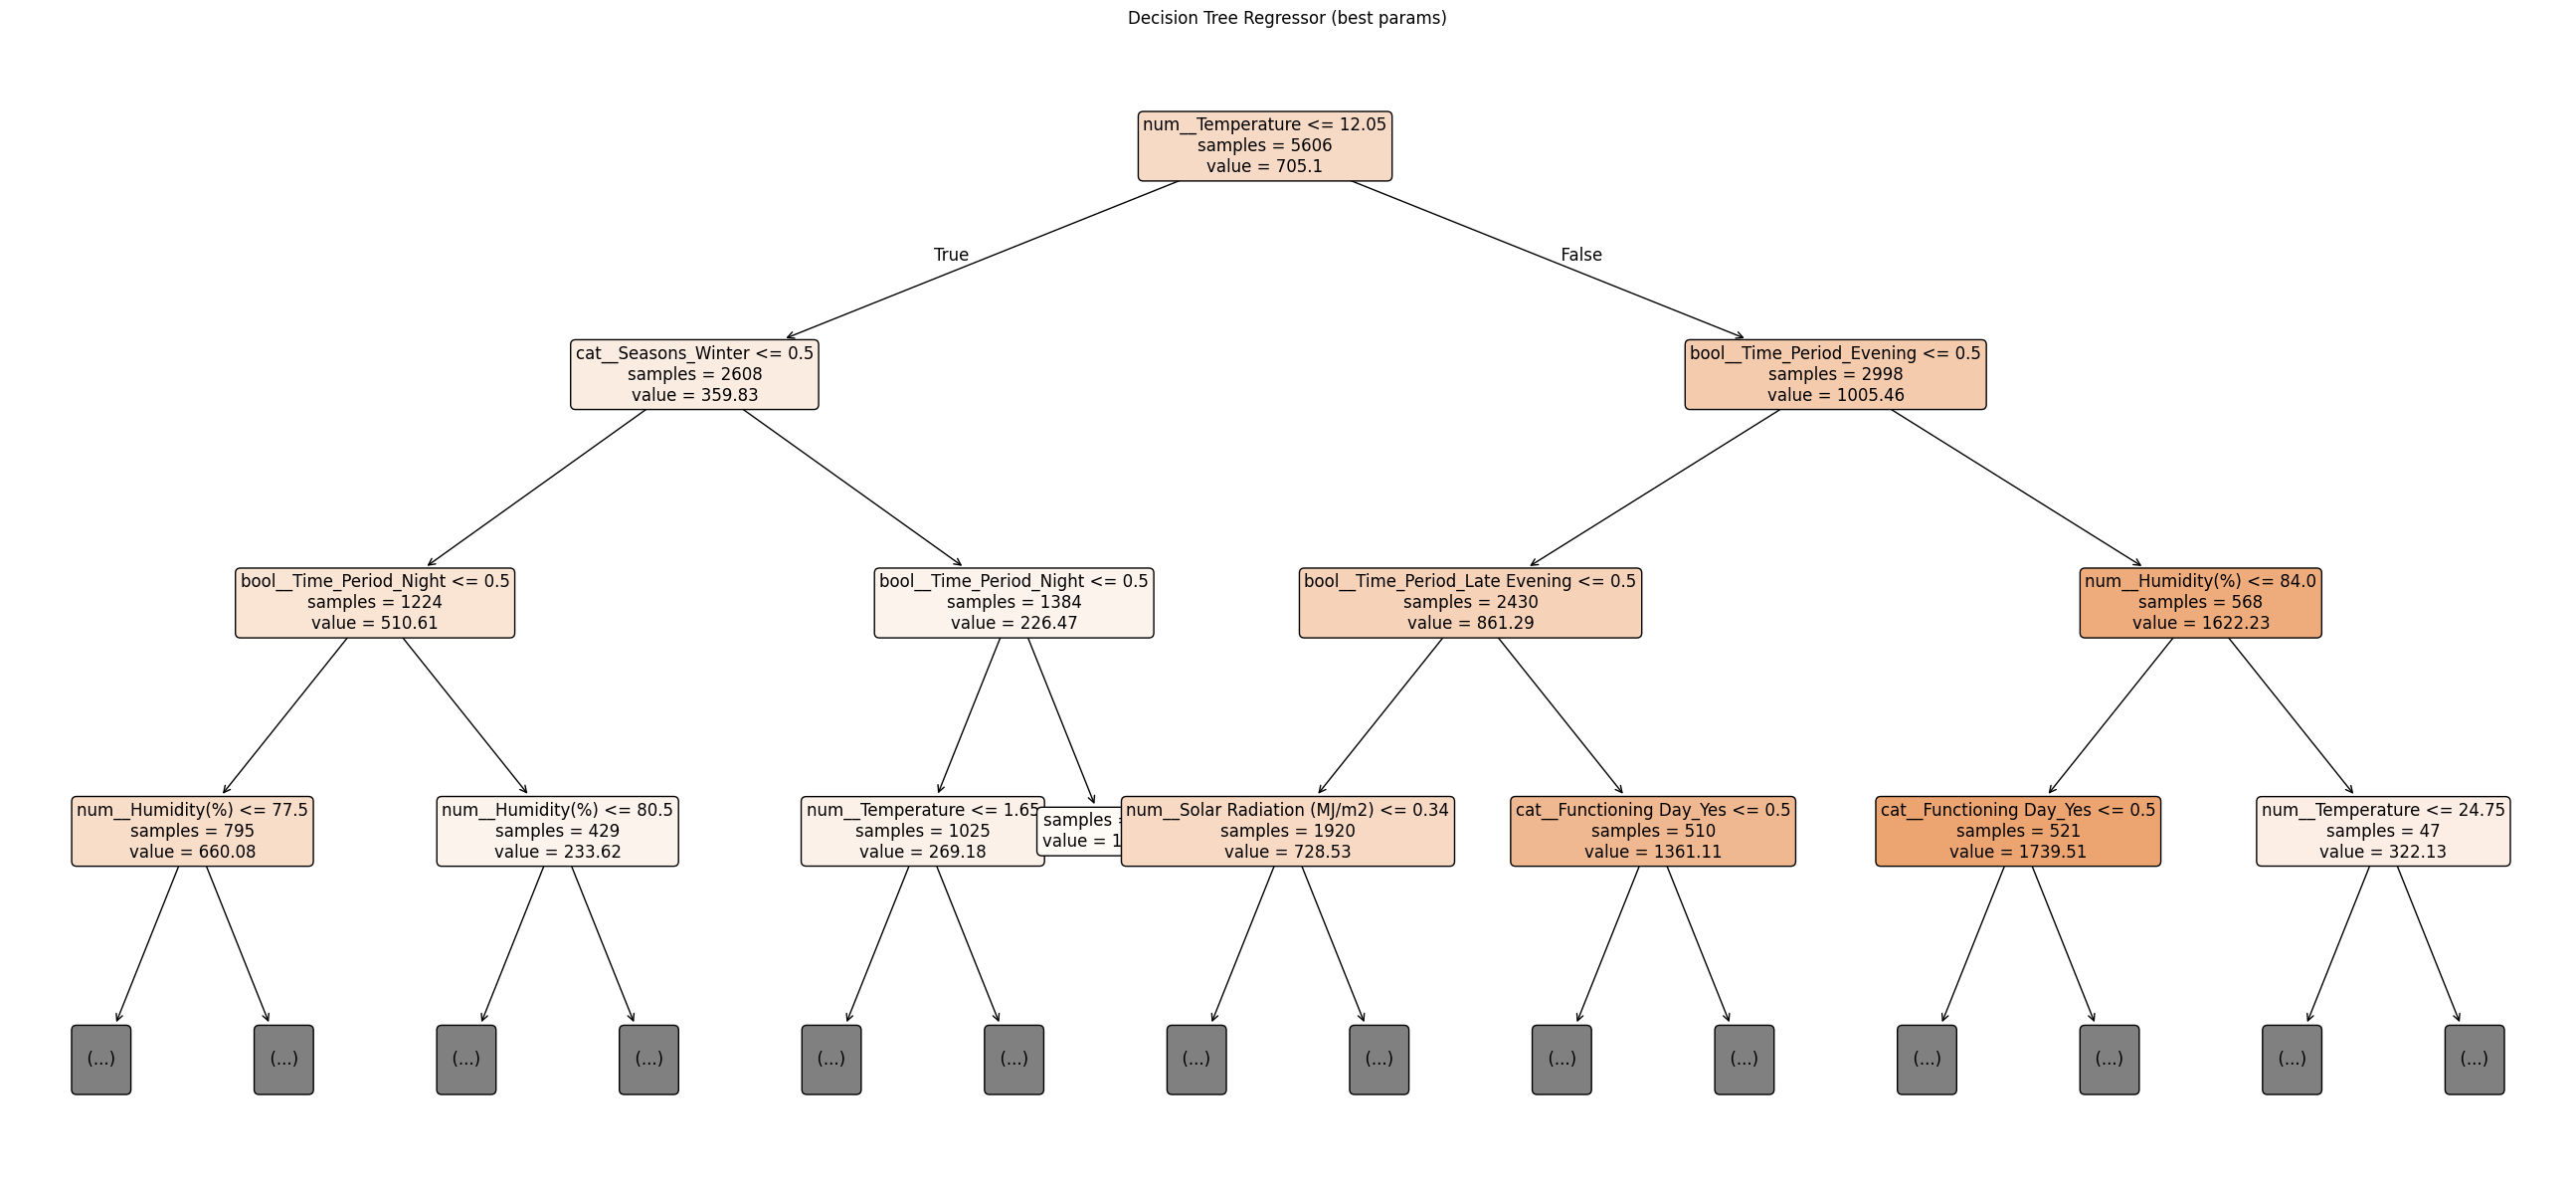

,feature,importance
0,num__Temperature,36.16%
13,bool__Time_Period_Evening,14.71%
12,cat__Functioning Day_Yes,11.30%
14,bool__Time_Period_Late Evening,8.66%
5,num__Solar Radiation (MJ/m2),8.59%
1,num__Humidity(%),7.39%
6,num__Rainfall(mm),4.43%
16,bool__Time_Period_Night,3.11%
10,cat__Seasons_Winter,2.82%
4,num__Dew point temperature,1.26%


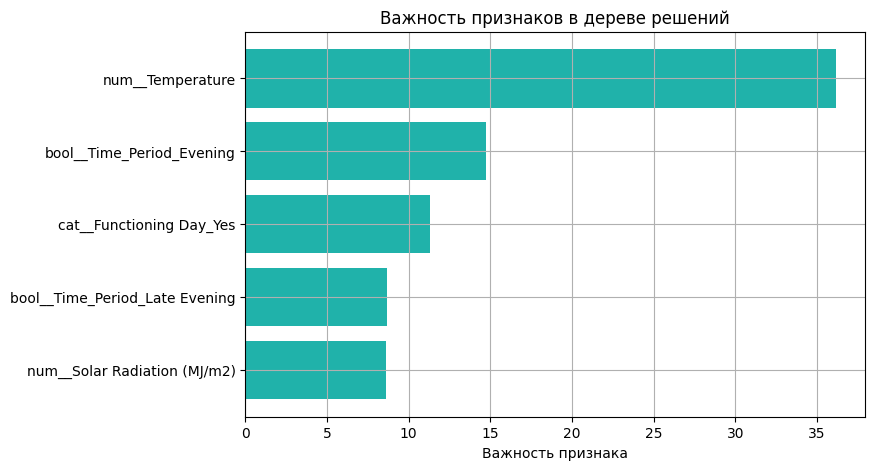

In [197]:
model = DecisionTreeRegressor(**study.best_params)
tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", model)
])

name = 'Decision Tree Regressor (best params)'
dtr_best_metrics_df = show_metrics(name, tree_pipeline)
show_tree_plot(name, tree_pipeline)
show_feature_importance(tree_pipeline)

#### Создание bagging моделей

,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Random Forest Regressor (baseline),291.29,190.87,0.80,27.08
1,Test,Random Forest Regressor (baseline),291.55,191.88,0.79,27.12


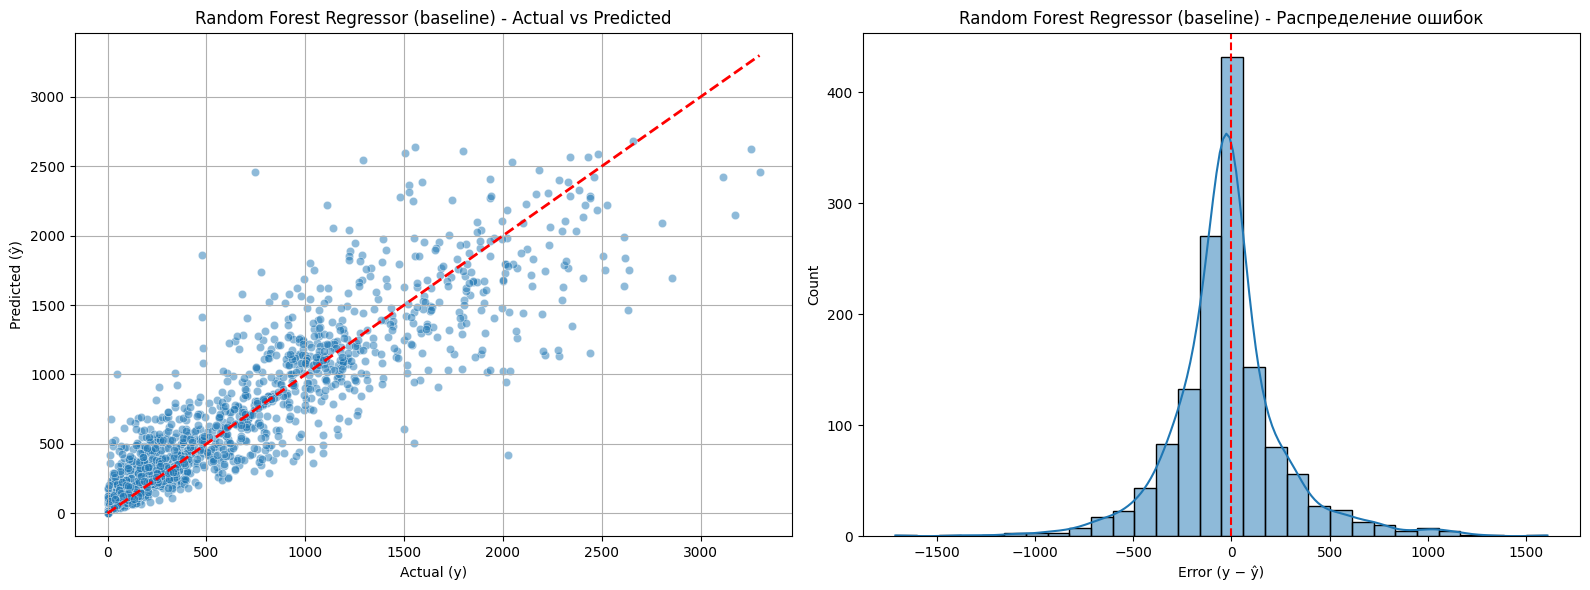

,feature,importance
0,num__Temperature,33.00%
1,num__Humidity(%),10.76%
13,bool__Time_Period_Evening,10.02%
12,cat__Functioning Day_Yes,8.48%
16,bool__Time_Period_Night,8.13%
5,num__Solar Radiation (MJ/m2),7.32%
14,bool__Time_Period_Late Evening,5.28%
4,num__Dew point temperature,4.42%
2,num__Wind speed (m/s),2.99%
3,num__Visibility (10m),2.96%


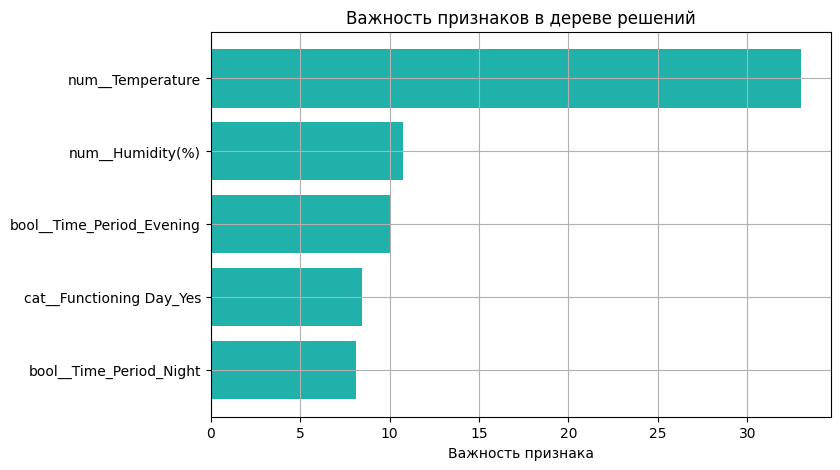

In [198]:
bagging_pipeline = Pipeline(steps=[
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

rfr_baseline_metrics_df = show_metrics('Random Forest Regressor (baseline)', bagging_pipeline)
show_feature_importance(bagging_pipeline)

In [199]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 35),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 0.1, log=True),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]) 
    }

    model = RandomForestRegressor(**params, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)
    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    mean_score = scores.mean()

    trial.report(mean_score, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=4)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 
bagging_best_params = study.best_params
print("Лучшие гиперпараметры:", bagging_best_params)
bagging_best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(bagging_best_value, 3))

[I 2026-02-13 16:49:09,453] A new study created in memory with name: no-name-b91fb8c8-bdb4-474a-a818-3e223caf85ed
Best trial: 3. Best value: 299.809:   4%|▍         | 2/50 [00:03<01:15,  1.57s/it]

[I 2026-02-13 16:49:13,019] Trial 0 finished with value: 302.6793386333688 and parameters: {'n_estimators': 283, 'max_depth': 24, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'ccp_alpha': 0.08531814909725252, 'criterion': 'friedman_mse'}. Best is trial 0 with value: 302.6793386333688.
[I 2026-02-13 16:49:13,193] Trial 3 finished with value: 299.80862780427736 and parameters: {'n_estimators': 233, 'max_depth': 28, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False, 'ccp_alpha': 6.0217020722507026e-05, 'criterion': 'squared_error'}. Best is trial 3 with value: 299.80862780427736.


Best trial: 2. Best value: 299.696:   6%|▌         | 3/50 [00:05<01:10,  1.49s/it]

[I 2026-02-13 16:49:14,587] Trial 2 finished with value: 299.6964547018848 and parameters: {'n_estimators': 396, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'ccp_alpha': 0.0004899881422896501, 'criterion': 'friedman_mse'}. Best is trial 2 with value: 299.6964547018848.


Best trial: 6. Best value: 288.114:   8%|▊         | 4/50 [00:08<01:45,  2.29s/it]

...

Best trial: 5. Best value: 283.323:  98%|█████████▊| 49/50 [01:13<00:01,  1.35s/it]

[I 2026-02-13 16:50:23,044] Trial 47 pruned. 


Best trial: 5. Best value: 283.323: 100%|██████████| 50/50 [01:14<00:00,  1.49s/it]

[I 2026-02-13 16:50:23,824] Trial 49 pruned. 


Лучшие гиперпараметры: {'n_estimators': 268, 'max_depth': 28, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False, 'ccp_alpha': 0.003224574031471206, 'criterion': 'friedman_mse'}
Лучшее среднее значение RMSE на кросс-валидации: 283.323


,Phase,Model,RMSE,MAE,R2,WAPE%
0,Cross-Val (Mean),Random Forest Regressor (best params),284.20,188.80,0.81,26.79
1,Test,Random Forest Regressor (best params),289.62,191.14,0.80,27.01


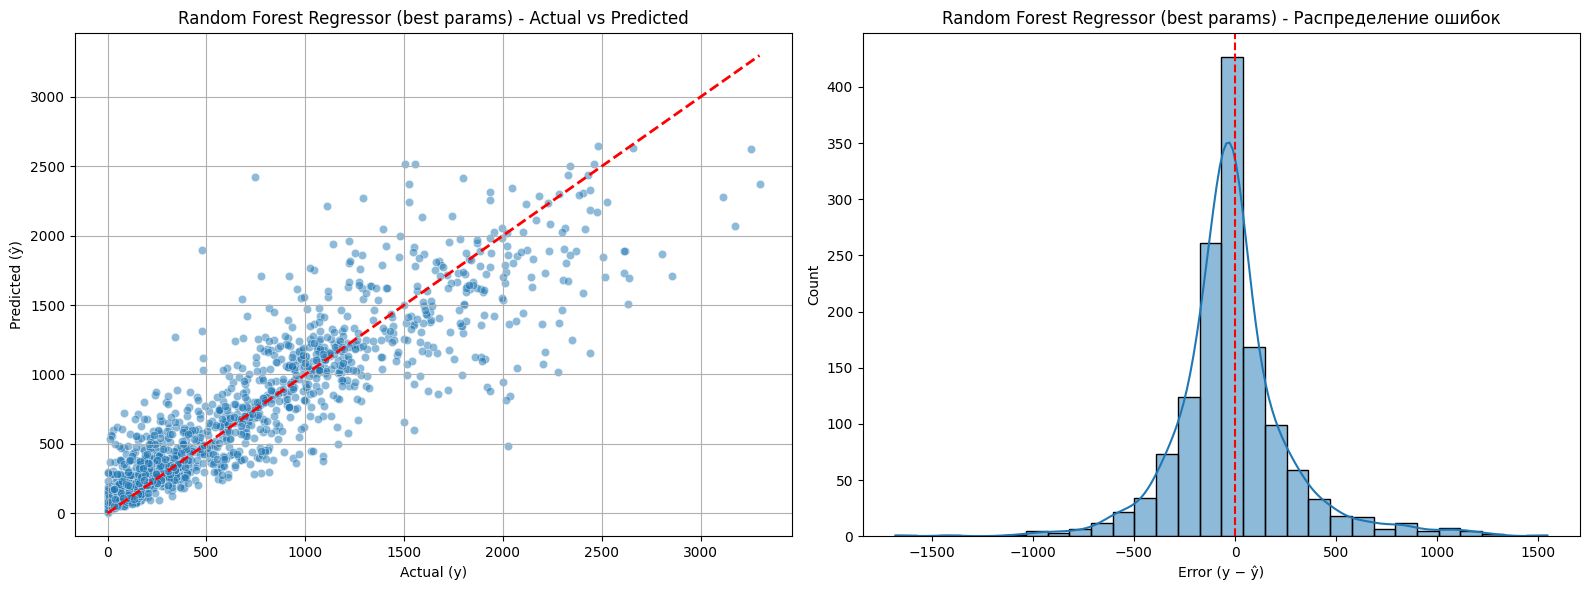

,feature,importance
0,num__Temperature,20.75%
13,bool__Time_Period_Evening,9.56%
1,num__Humidity(%),9.37%
4,num__Dew point temperature,8.82%
16,bool__Time_Period_Night,8.55%
10,cat__Seasons_Winter,7.96%
5,num__Solar Radiation (MJ/m2),7.76%
12,cat__Functioning Day_Yes,7.22%
14,bool__Time_Period_Late Evening,4.42%
3,num__Visibility (10m),4.19%


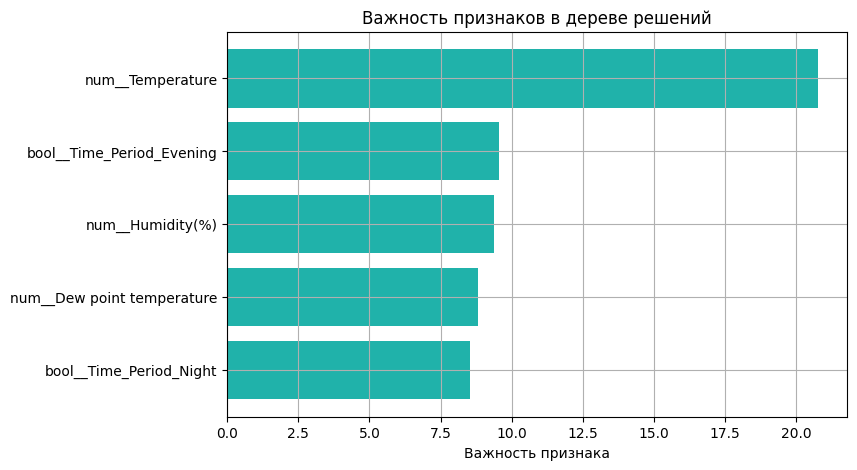

In [200]:
model = RandomForestRegressor(**study.best_params)
bagging_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", model)
])

rfr_best_metrics_df = show_metrics('Random Forest Regressor (best params)', bagging_pipeline)
show_feature_importance(bagging_pipeline)

---

,Phase,Model,RMSE,MAE,R2,WAPE%
14,Cross-Val (Mean),Random Forest Regressor (best params),284.20,188.80,0.81,26.79
15,Test,Random Forest Regressor (best params),289.62,191.14,0.80,27.01
12,Cross-Val (Mean),Random Forest Regressor (baseline),291.29,190.87,0.80,27.08
13,Test,Random Forest Regressor (baseline),291.55,191.88,0.79,27.12
10,Cross-Val (Mean),Decision Tree Regressor (best params),319.59,216.58,0.76,30.73
4,Cross-Val (Mean),KNN (filted),327.06,219.10,0.74,31.08
11,Test,Decision Tree Regressor (best params),327.42,221.62,0.74,31.32
6,Cross-Val (Mean),KNN (best params),329.05,227.63,0.74,32.30
5,Test,KNN (filted),334.61,222.30,0.73,31.41
7,Test,KNN (best params),340.24,231.98,0.72,32.78


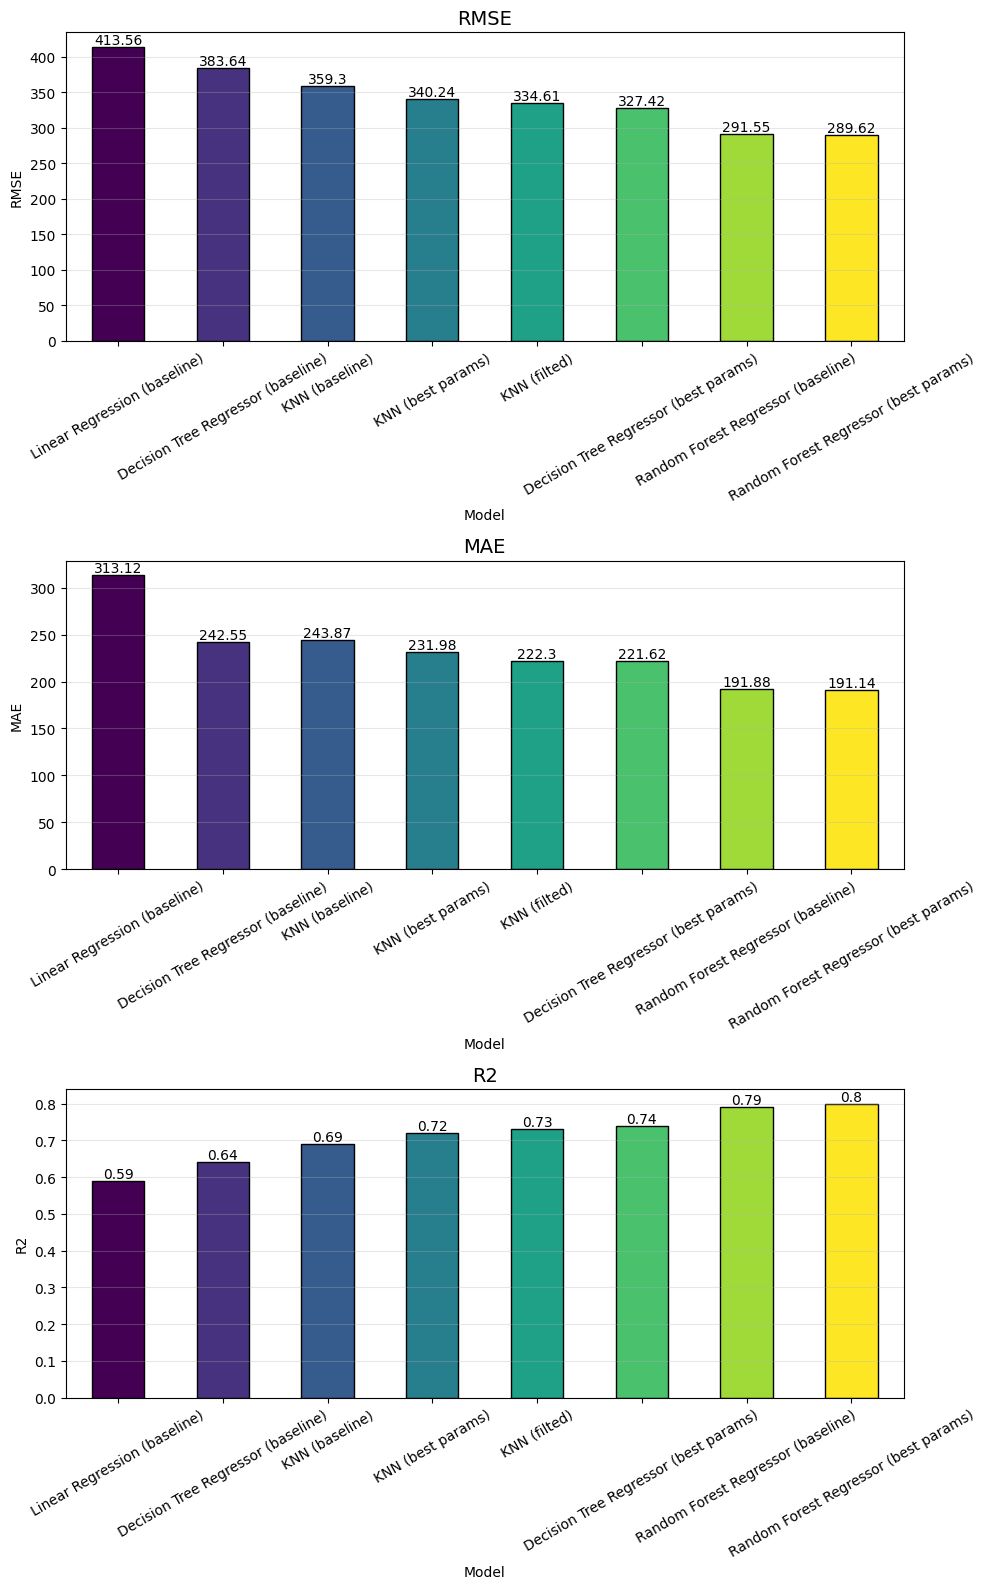

In [201]:
summary_df = pd.concat(
    [
        lr_metrics_df, 
        knn_baseline_metrics_df, 
        knn_filted_metrics_df, 
        knn_best_metrics_df, 
        dtr_baseline_metrics_df, 
        dtr_best_metrics_df, 
        rfr_baseline_metrics_df, 
        rfr_best_metrics_df
    ], ignore_index=True,
).sort_values(by="RMSE", ascending=False)

display(summary_df.sort_values(by="RMSE", ascending=True))

test_df = summary_df[summary_df["Phase"] == "Test"].set_index("Model")

fig, axes = plt.subplots(3, 1, figsize=(10, 16))
cmap = plt.get_cmap('viridis')
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    colors = cmap(np.linspace(0, 1, len(test_df)))
    test_df[metric].plot.bar(ax=ax, edgecolor="black", color=colors)
    
    ax.set_title(metric, fontsize=14)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)
    ax.bar_label(ax.containers[0])
    
plt.tight_layout()
plt.show()

---

#### Выводы:

Вот итоговый анализ работы, разбитый на логические блоки для удобства чтения заказчиком.

**Выбор оптимальной модели**

С технической точки зрения, наилучший результат показал алгоритм Random Forest (случайный лес). Он дает самую низкую ошибку (RMSE около 290) и объясняет 80% закономерностей в данных. Однако, так как эта тема еще не изучалась в рамках курса, данная модель в финальное решение не войдет.

В качестве итоговой модели выбрано дерево решений (Decision Tree) с подобранными гиперпараметрами.
Оно показало себя значительно лучше, чем линейная регрессия (MSE 321 против 414) и метод ближайших соседей. Эта модель обеспечивает оптимальный баланс между точностью и понятностью интерпретации результатов.

**Что влияет на спрос (Ключевые факторы)**

Модель выделила конкретные показатели, которые сильнее всего определяют, сколько велосипедов возьмут в прокат:

1.  **Температура (36.08%)** - это самый важный фактор. Спрос критически зависит от того, тепло на улице или холодно.
2.  **Вечернее время (суммарно более 23%)** - факторы "Вечер" (14.74%) и "Поздний вечер" (8.68%) идут следом. Люди активно пользуются сервисом после работы и для прогулок перед сном.
3.  **Рабочий статус системы (11.16%)** - признак "Functioning Day" показывает, что технические перерывы или выходные дни сервиса кардинально меняют картину потребления.
4.  **Солнечная радиация (8.48%)** - ясная, солнечная погода дополнительно стимулирует спрос.

**Бизнес-вывод**

Для планирования загрузки станций следует опираться в первую очередь на **температурный прогноз**.
*   Модель чувствительна к теплу: ожидайте резкий рост аренды в теплые дни.
*   Вечерний пик: готовьте максимальное количество исправных велосипедов к временному слоту после 18:00, так как это самое активное время использования.
*   График работы персонала: В дни с хорошим прогнозом погоды стоит выводить больше сотрудников техподдержки и сервиса, так как нагрузка на систему гарантированно вырастет.

---

In [202]:
model_file_name = './models/new_model.joblib'

metadata = {
    'model_version': '1.0.0',
    'training_date': '2026-02-13',
    'best_score': tree_best_value,
    'best_params': tree_best_params,
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__
}

joblib.dump({
    'pipeline': tree_pipeline,
    'metadata': metadata,
}, model_file_name)

print(f"Объект сохранён в файл {model_file_name}") 

Объект сохранён в файл ./models/new_model.joblib


In [203]:
class SouthernWeatherPredictionService:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)

    def predict_forecasting(self, data):
        return self.model['pipeline'].predict(data)

In [204]:
service = SouthernWeatherPredictionService(model_file_name)
result = service.predict_forecasting(test)

submission = pd.DataFrame({
    'Rented Bike Count': result
})

submission.to_csv('datasets/submissions.csv', index=False)